In [1]:
import numpy as np
import pandas as pd

import random

np.random.seed(42)

n = 20500

Name = [f"Stud{str(i).zfill(5)}" for i in range(1, n+1)]

Number = np.arange(1, n+1)

Enrollment_Date = pd.to_datetime(
    np.random.choice(pd.date_range("2020-01-01", "2025-12-31"), n)
)

ten_yop = np.random.randint(2015, 2018, n)
ten_per = np.random.randint(50, 100, n)

twelve_yop = ten_yop + 2
twelve_per = np.random.randint(50, 100, n)

degree_yop = (twelve_yop + 3).astype(float)
degree_per = np.random.uniform(50, 90, n)

masters_yop = (degree_yop + 2)
masters_per = np.random.uniform(50, 90, n)

branch = np.random.choice(["PySpiders", "JSpiders", "QSpiders"], n)
course = np.random.choice(["Python FullStack", "Java FullStack", "Testing"], n)
FSDI = np.random.choice(["Yes", "No"], n)

Requirement_count = np.random.randint(0, 50, n)

Placement_status = np.random.choice(["Placed", "Not Placed"], n)

package = np.random.uniform(3, 15, n)

def insert_nan(arr, non_null_count):
    arr = pd.Series(arr)
    null_indices = np.random.choice(arr.index, size=(n - non_null_count), replace=False)
    arr.loc[null_indices] = np.nan
    return arr

degree_yop = insert_nan(degree_yop, 10317)
degree_per = insert_nan(degree_per, 10317)
masters_yop = insert_nan(masters_yop, 10317)
masters_per = insert_nan(masters_per, 10317)
package = insert_nan(package, 19283)

df = pd.DataFrame({
    "Name": Name,
    "Number": Number,
    "Enrollment_Date": Enrollment_Date,
    "10_yop": ten_yop,
    "10_per": ten_per,
    "12_yop": twelve_yop,
    "12_per": twelve_per,
    "degree_yop": degree_yop,
    "degree_per": degree_per,
    "masters_yop": masters_yop,
    "masters_per": masters_per,
    "branch": branch,
    "course": course,
    "FSDI": FSDI,
    "Requirement_count": Requirement_count,
    "Placement_status": Placement_status,
    "package": package
})

In [2]:
df

,Name,Number,Enrollment_Date,10_yop,10_per,12_yop,12_per,degree_yop,degree_per,masters_yop,masters_per,branch,course,FSDI,Requirement_count,Placement_status,package
0,Stud00001,1,2022-05-10,2016,93,2018,78,2021.0,NaN,2023.0,61.192678,PySpiders,Testing,Yes,3,Placed,13.461957
1,Stud00002,2,2023-07-18,2017,60,2019,68,NaN,58.244181,2024.0,70.726321,JSpiders,Python FullStack,No,0,Not Placed,6.314052
2,Stud00003,3,2023-02-04,2015,96,2017,84,NaN,61.476027,2022.0,71.973305,QSpiders,Python FullStack,Yes,32,Not Placed,6.101702
3,Stud00004,4,2022-12-31,2016,75,2018,74,2021.0,NaN,2023.0,NaN,JSpiders,Java FullStack,Yes,43,Placed,14.151358
4,Stud00005,5,2024-06-26,2016,85,2018,97,NaN,70.930286,2023.0,51.893125,JSpiders,Testing,Yes,25,Not Placed,9.731116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20495,Stud20496,20496,2020-04-24,2017,68,2019,70,NaN,64.233878,2024.0,87.277097,QSpiders,Java FullStack,Yes,1,Not Placed,9.328621
20496,Stud20497,20497,2021-01-07,2015,92,2017,60,2020.0,62.108717,2022.0,NaN,QSpiders,Python FullStack,No,25,Not Placed,13.408417
20497,Stud20498,20498,2022-04-29,2016,74,2018,90,2021.0,54.013561,2023.0,83.756790,JSpiders,Python FullStack,Yes,16,Not Placed,11.757958
20498,Stud20499,20499,2025-11-07,2015,87,2017,85,2020.0,57.945448,2022.0,81.692193,PySpiders,Testing,No,34,Not Placed,4.236719


In [3]:
import matplotlib.pyplot as plt

In [4]:
df['enrollment_date'] = df['Enrollment_Date'].astype('datetime64[s]')
df['Year'] = df['Enrollment_Date'].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20500 entries, 0 to 20499
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   Name               20500 non-null  object       
 1   Number             20500 non-null  int64        
 2   Enrollment_Date    20500 non-null  datetime64[s]
 3   10_yop             20500 non-null  int64        
 4   10_per             20500 non-null  int64        
 5   12_yop             20500 non-null  int64        
 6   12_per             20500 non-null  int64        
 7   degree_yop         10317 non-null  float64      
 8   degree_per         10317 non-null  float64      
 9   masters_yop        10317 non-null  float64      
 10  masters_per        10317 non-null  float64      
 11  branch             20500 non-null  object       
 12  course             20500 non-null  object       
 13  FSDI               20500 non-null  object       
 14  Requirement_count  205

In [ ]:
a= df.groupby('Year')['Number'].count()
a

,Number
Year,
2020,3281
2021,3402
2022,3477
2023,3415
2024,3505
2025,3420


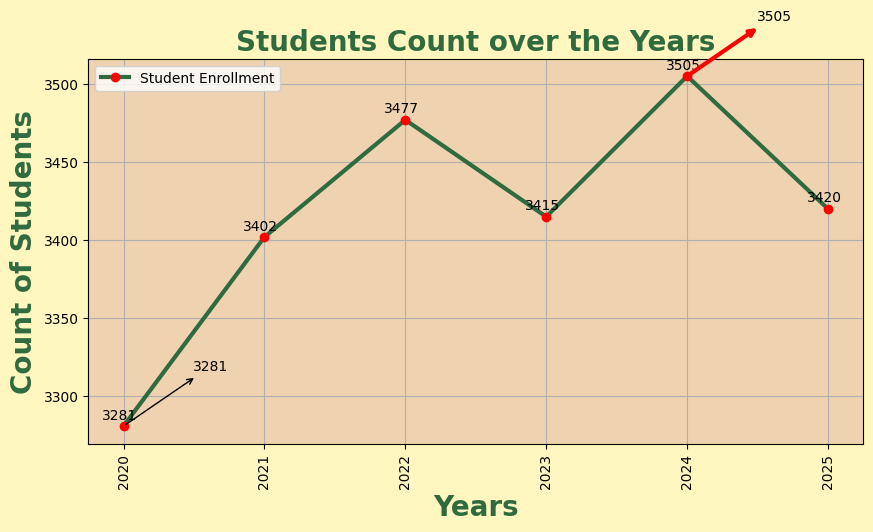

In [ ]:
plt.figure(figsize=(10,5),facecolor='#FFF6C0')
a.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='#2F6B3F',fontsize=20,fontweight='bold')
plt.ylabel('Count of Students',color='#2F6B3F',fontsize=20,fontweight='bold')
plt.title('Students Count over the Years',color='#2F6B3F',fontsize=20,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')

plt.xticks(a.index,rotation=90)

for i ,j in zip(a.index,a.values):
    plt.annotate(j,(i,j),ha='right',textcoords='offset points',xytext=(10,5))

max= a.idxmax()
min = a.idxmin()

plt.annotate(a[max],(max,a[max]) , color='black',textcoords='offset points',xytext=(50,40),arrowprops=dict(arrowstyle='<-',lw=3,color='red'))
plt.annotate(a[min],(min,a[min]), color='black',textcoords='offset points',xytext=(50,40),arrowprops=dict(arrowstyle='<-'))

plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
#Is placed student increaving or decreasing

placed_over_time=df.groupby(['Placement_status'])['Name'].count()
placed_over_time




,Name
Placement_status,
Not Placed,10429
Placed,10071


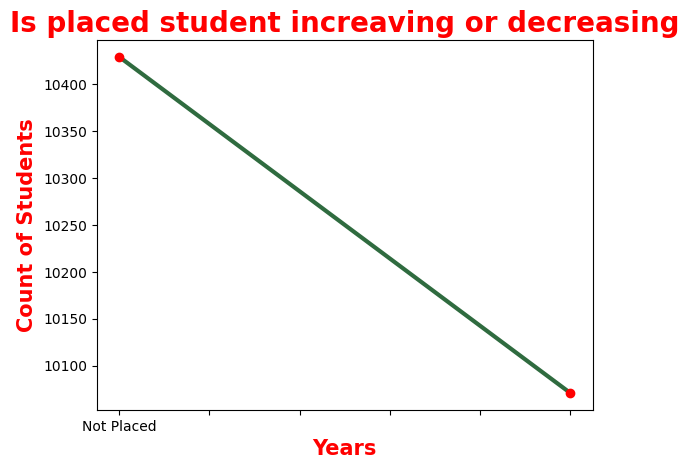

In [ ]:
placed_over_time.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=15,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=15,fontweight='bold')
plt.title('Is placed student increaving or decreasing',color='red',fontsize=20,fontweight='bold')
plt.show()

In [ ]:
#How has the average package changed year by year?
avg_package=df.groupby('Year')['package'].mean()

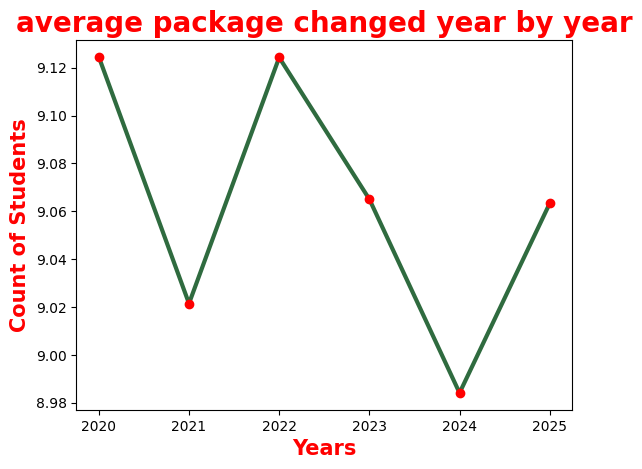

In [ ]:
avg_package.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=15,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=15,fontweight='bold')
plt.title('average package changed year by year',color='red',fontsize=20,fontweight='bold')
plt.show()

In [ ]:
#Is student average academic performance improving over the years?
df['avg_academic']=df[['10_per','12_per','degree_per','masters_per']].mean(axis=1)
academic_trend=df.groupby('Year')['avg_academic'].mean()

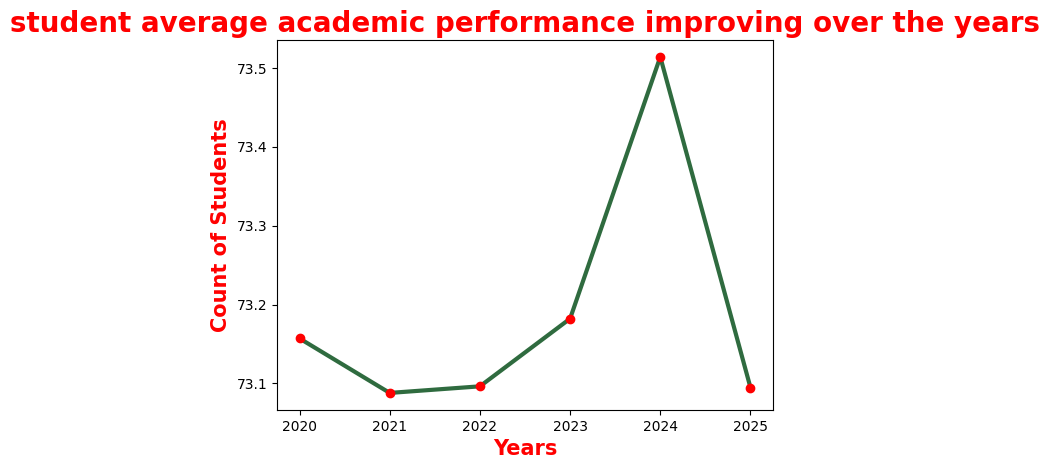

In [ ]:
academic_trend.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=15,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=15,fontweight='bold')
plt.title('student average academic performance improving over the years',color='red',fontsize=20,fontweight='bold')
plt.show()

In [ ]:
#Are students making more attempts (Requirement_count) over the years?
attempts=df.groupby('Year')['Requirement_count'].mean()
attempts

,Requirement_count
Year,
2020,25.154526
2021,25.037331
2022,24.511073
2023,24.958126
2024,24.247361
2025,24.530117


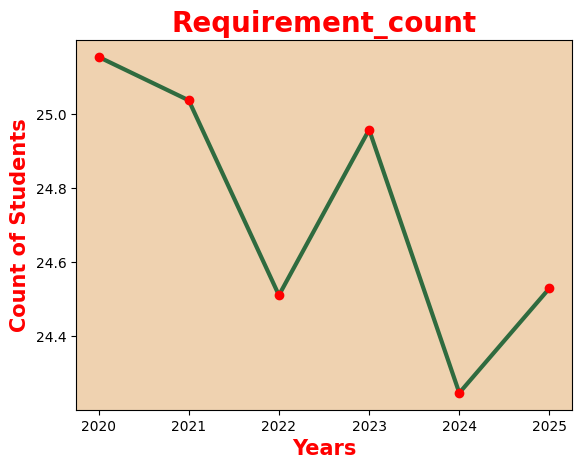

In [ ]:
attempts.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=15,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=15,fontweight='bold')
plt.title('Requirement_count',color='red',fontsize=20,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')
plt.show()


In [ ]:
#how as student enrollment changed over the year for each branch
batch =pd.pivot_table(df,index='Year',columns='branch',values='Number',aggfunc='count')
batch

branch,JSpiders,PySpiders,QSpiders
Year,,,
2020,1131,1085,1065
2021,1143,1071,1188
2022,1190,1177,1110
2023,1136,1172,1107
2024,1177,1155,1173
2025,1180,1118,1122


<Figure size 1000x500 with 0 Axes>

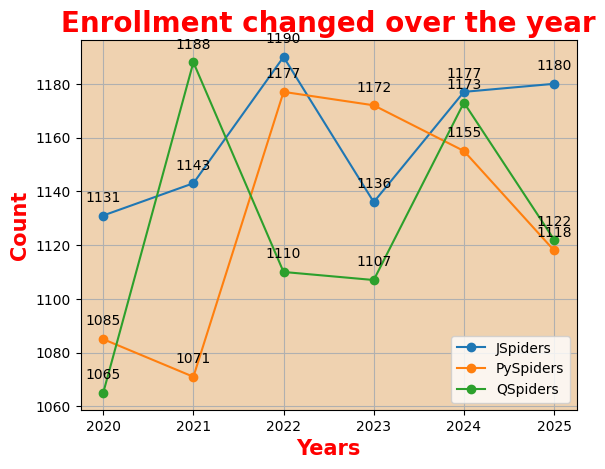

In [ ]:
plt.figure(figsize=(10,5),facecolor='#FFF6C0')
batch.plot(marker='o')
plt.xlabel('Years',color='red',fontsize=15,fontweight='bold')
plt.ylabel('Count',color='red',fontsize=15,fontweight='bold')
plt.title('Enrollment changed over the year',color='red',fontsize=20,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')
for i in batch.columns:
  for i,j in zip(batch.index,batch[i]):
    plt.annotate(int(j),(i,j),ha='center',textcoords='offset points',xytext=(0,10))
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
#Which course are gainingor loosing popularity over the year
course_data=df.groupby(['Year','course'])['Number'].count().unstack()
course_data

course,Java FullStack,Python FullStack,Testing
Year,,,
2020,1113,1101,1067
2021,1071,1162,1169
2022,1170,1142,1165
2023,1112,1151,1152
2024,1200,1134,1171
2025,1133,1179,1108


<Figure size 800x600 with 0 Axes>

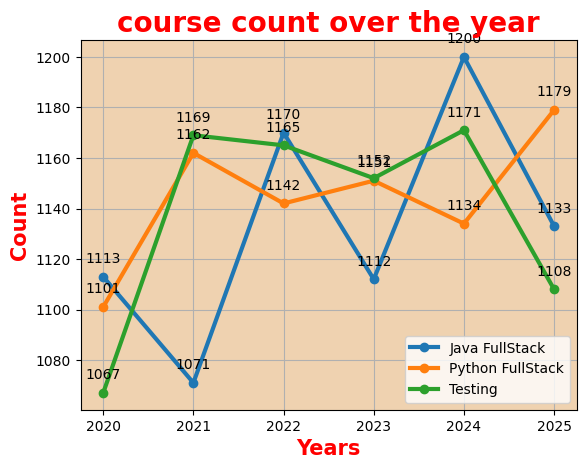

In [ ]:
plt.figure(figsize=(8,6),facecolor='red')
course_data.plot(marker='o',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=15,fontweight='bold')
plt.ylabel('Count',color='red',fontsize=15,fontweight='bold')
plt.title('course count over the year',color='red',fontsize=20,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')
for col in course_data.columns:
    for i, j in zip(course_data.index, course_data[col]):
        plt.annotate(int(j), (i, j), ha='center',textcoords='offset points',xytext=(0,10))
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
df.head()

,Name,Number,Enrollment_Date,10_yop,10_per,12_yop,12_per,degree_yop,degree_per,masters_yop,masters_per,branch,course,FSDI,Requirement_count,Placement_status,package,Year,avg_academic
0,Stud00001,1,2022-05-10,2016,93,2018,78,2021.0,NaN,2023.0,61.192678,PySpiders,Testing,Yes,3,Placed,13.461957,2022,77.397559
1,Stud00002,2,2023-07-18,2017,60,2019,68,NaN,58.244181,2024.0,70.726321,JSpiders,Python FullStack,No,0,Not Placed,6.314052,2023,64.242626
2,Stud00003,3,2023-02-04,2015,96,2017,84,NaN,61.476027,2022.0,71.973305,QSpiders,Python FullStack,Yes,32,Not Placed,6.101702,2023,78.362333
3,Stud00004,4,2022-12-31,2016,75,2018,74,2021.0,NaN,2023.0,NaN,JSpiders,Java FullStack,Yes,43,Placed,14.151358,2022,74.500000
4,Stud00005,5,2024-06-26,2016,85,2018,97,NaN,70.930286,2023.0,51.893125,JSpiders,Testing,Yes,25,Not Placed,9.731116,2024,76.205853


In [ ]:
#Is the placement success rate improving overtime
placement=pd.pivot_table(df,index='Year',values='Placement_status', aggfunc=lambda x: (x=='Placed').mean()*100)
placement

,Placement_status
Year,
2020,47.485523
2021,49.088771
2022,49.496693
2023,48.199122
2024,49.015692
2025,51.403509


<Figure size 1000x600 with 0 Axes>

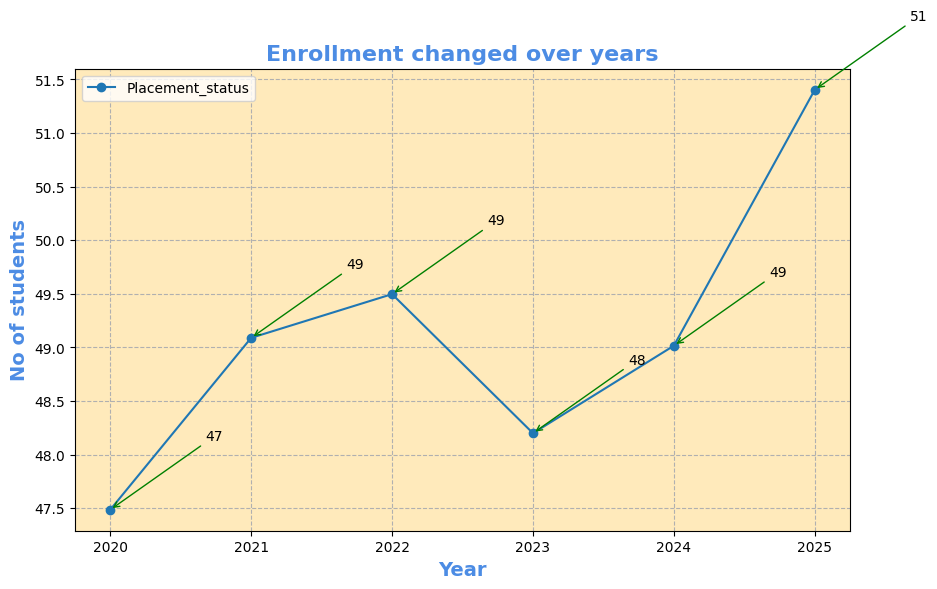

In [ ]:
plt.figure(figsize=(10, 6), facecolor='#FFF6C0')
ax = placement.plot(marker='o', figsize=(10, 6))
plt.xlabel('Year', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.ylabel('No of students', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.title('Enrollment changed over years', fontsize=16, fontweight='bold', color='#4C8CE4')

for col in placement.columns:
    for i, j in zip(placement.index, placement[col]):
        plt.annotate(int(j), (i, j), ha='center', textcoords='offset points', xytext=(75, 50),arrowprops=dict(arrowstyle='->',lw=1,color='green'))

ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(placement.index)
plt.grid(True, linestyle='--')
plt.legend()

plt.show()

In [ ]:
#How has enrollment of technical vs non technical changed overtime
fsdi_enrollment = pd.pivot_table(df,index='Year',columns='FSDI',values='Number',aggfunc='count')
fsdi_enrollment

FSDI,No,Yes
Year,,
2020,1650,1631
2021,1706,1696
2022,1773,1704
2023,1722,1693
2024,1746,1759
2025,1702,1718


<Figure size 1000x600 with 0 Axes>

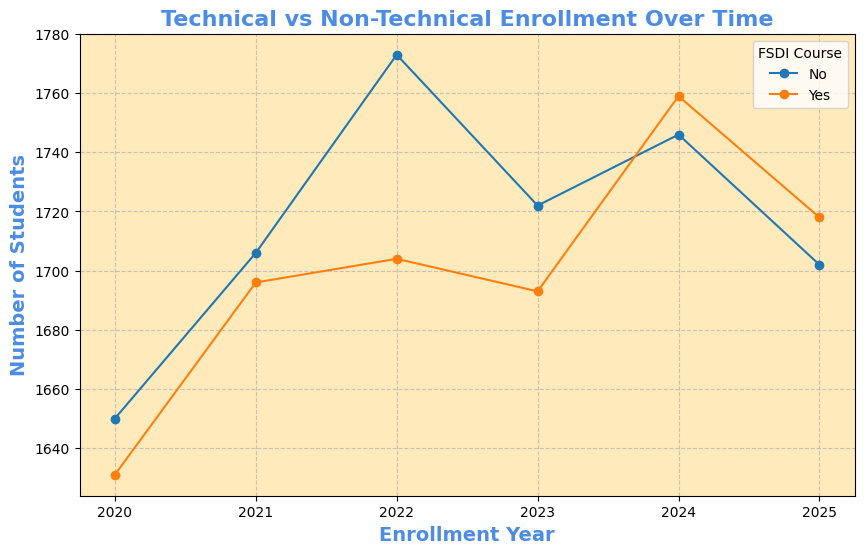

In [ ]:
plt.figure(figsize=(10, 6), facecolor='#FFF6C0')
ax = fsdi_enrollment.plot(marker='o', figsize=(10, 6))

plt.xlabel('Enrollment Year', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.ylabel('Number of Students', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.title('Technical vs Non-Technical Enrollment Over Time', fontsize=16, fontweight='bold', color='#4C8CE4')

#for col in fsdi_enrollment.columns:
    #for i, j in zip(fsdi_enrollment.index, fsdi_enrollment[col]):
        #plt.annotate(int(j), (i, j), ha='center', textcoords='offset points', xytext=(0, 10))

ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(fsdi_enrollment.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='FSDI Course')

plt.show()

In [ ]:
df.head()

,Name,Number,Enrollment_Date,10_yop,10_per,12_yop,12_per,degree_yop,degree_per,masters_yop,masters_per,branch,course,FSDI,Requirement_count,Placement_status,package,Year,avg_academic
0,Stud00001,1,2022-05-10,2016,93,2018,78,2021.0,NaN,2023.0,61.192678,PySpiders,Testing,Yes,3,Placed,13.461957,2022,77.397559
1,Stud00002,2,2023-07-18,2017,60,2019,68,NaN,58.244181,2024.0,70.726321,JSpiders,Python FullStack,No,0,Not Placed,6.314052,2023,64.242626
2,Stud00003,3,2023-02-04,2015,96,2017,84,NaN,61.476027,2022.0,71.973305,QSpiders,Python FullStack,Yes,32,Not Placed,6.101702,2023,78.362333
3,Stud00004,4,2022-12-31,2016,75,2018,74,2021.0,NaN,2023.0,NaN,JSpiders,Java FullStack,Yes,43,Placed,14.151358,2022,74.500000
4,Stud00005,5,2024-06-26,2016,85,2018,97,NaN,70.930286,2023.0,51.893125,JSpiders,Testing,Yes,25,Not Placed,9.731116,2024,76.205853


In [ ]:
#Are high performance student increasing over the years or not
df['Average_Academic_Percentage'] = df[['10_per', '12_per', 'degree_per']].mean(axis=1)

high_performers = df[df['Average_Academic_Percentage'] > 80]

high_performer_enrollment = high_performers.groupby('Year')['Number'].count()
high_performer_enrollment

,Number
Year,
2020,802
2021,806
2022,842
2023,845
2024,926
2025,820


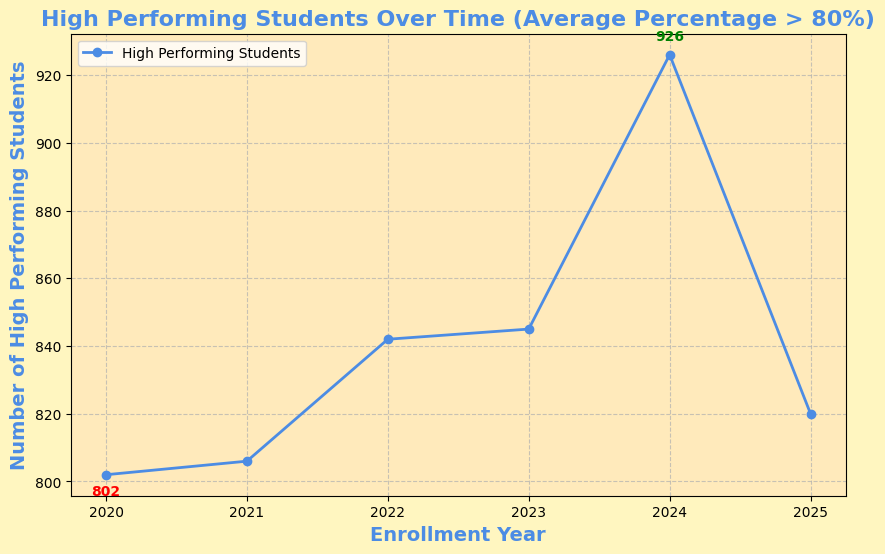

In [ ]:
plt.figure(figsize=(10, 6), facecolor='#FFF6C0')
plt.plot(high_performer_enrollment.index, high_performer_enrollment.values, marker='o', color='#4C8CE4', linewidth=2, label='High Performing Students')

# Annotate max and min values
max_hp_value = high_performer_enrollment.max()
min_hp_value = high_performer_enrollment.min()
max_hp_year = high_performer_enrollment.idxmax()
min_hp_year = high_performer_enrollment.idxmin()

plt.annotate(f'{int(max_hp_value)}', (max_hp_year, max_hp_value), textcoords="offset points", xytext=(0,10), ha='center', color='green', fontsize=10, fontweight='bold')
plt.annotate(f'{int(min_hp_value)}', (min_hp_year, min_hp_value), textcoords="offset points", xytext=(0,-15), ha='center', color='red', fontsize=10, fontweight='bold')

plt.xlabel('Enrollment Year', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.ylabel('Number of High Performing Students', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.title('High Performing Students Over Time (Average Percentage > 80%)', fontsize=16, fontweight='bold', color='#4C8CE4')

ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(high_performer_enrollment.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

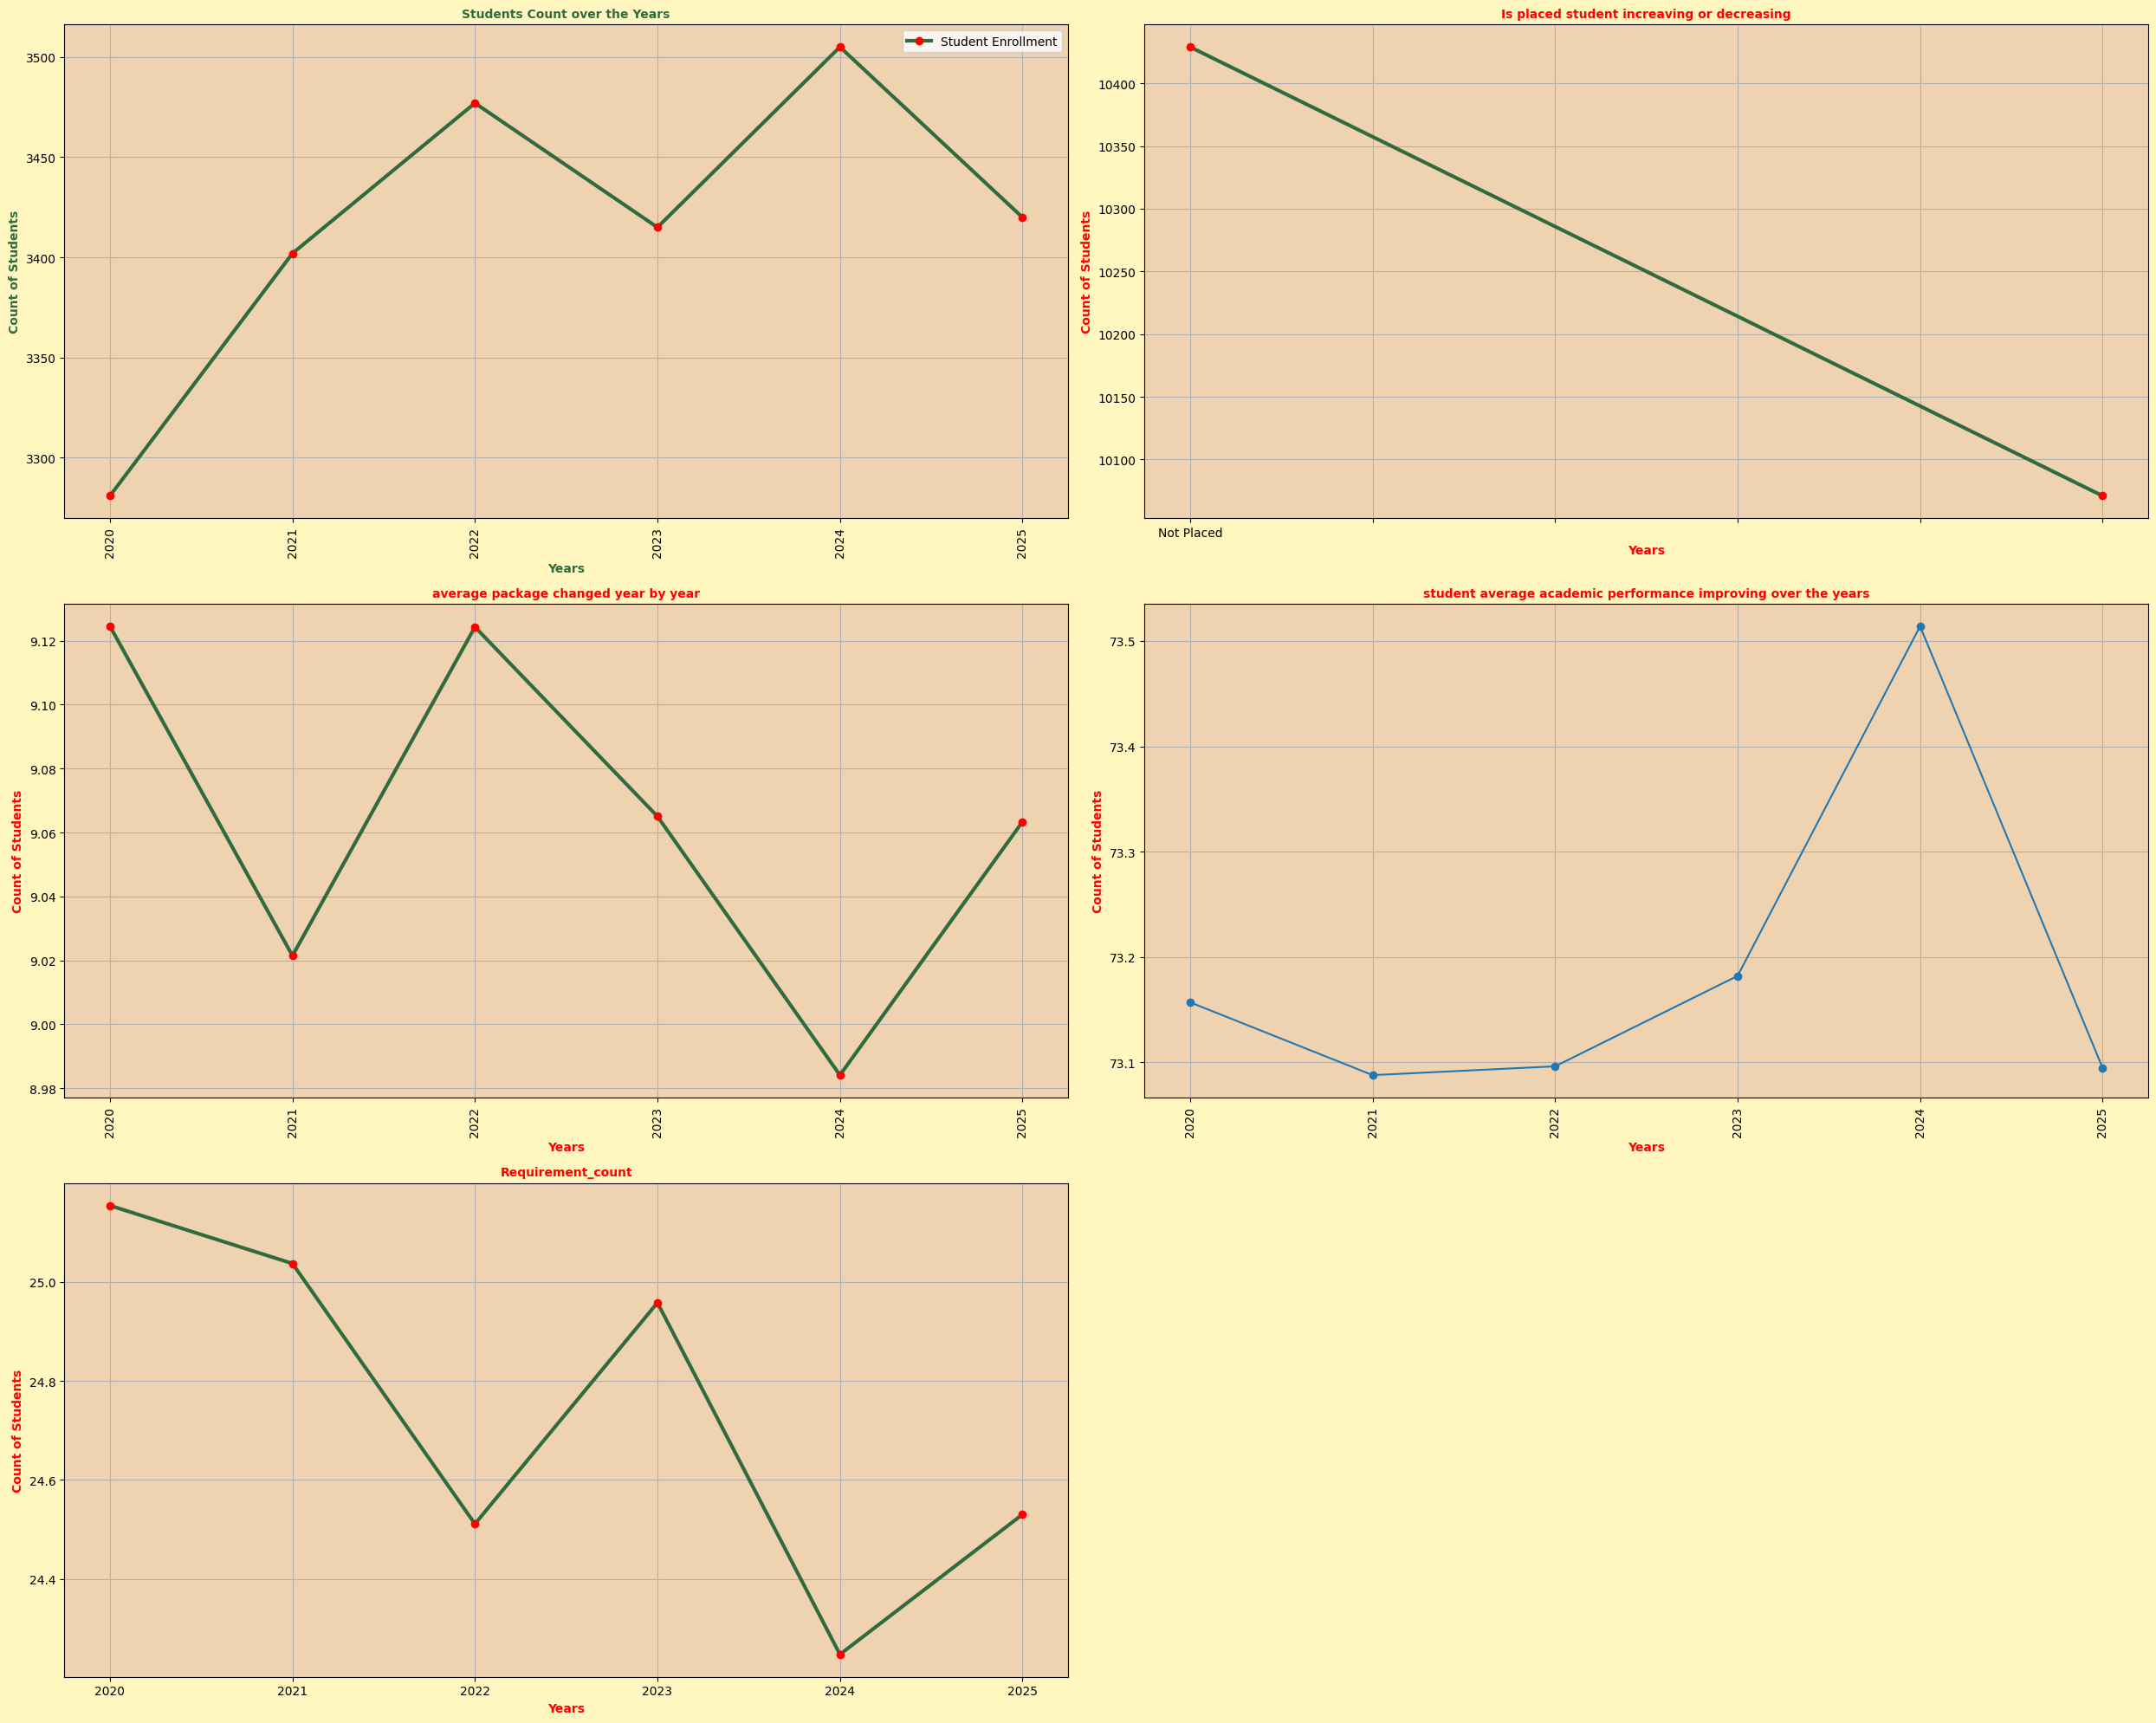

In [ ]:
plt.figure(figsize=(25, 20),facecolor='#FFF6C0')
#1
plt.subplot(3,2,1)
a= df.groupby('Year')['Number'].count()
a.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='#2F6B3F',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='#2F6B3F',fontsize=10,fontweight='bold')
plt.title('Students Count over the Years',color='#2F6B3F',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')
plt.xticks(a.index,rotation=90)
#for i ,j in zip(a.index,a.values):
    #plt.annotate(j,(i,j),ha='right',textcoords='offset points',xytext=(10,5))
# max= a.idxmax()
# min = a.idxmin()
# plt.annotate(a[max],(max,a[max]) , color='black',textcoords='offset points',xytext=(50,40),arrowprops=dict(arrowstyle='<-',lw=3,color='red'))
# plt.annotate(a[min],(min,a[min]), color='black',textcoords='offset points',xytext=(50,40),arrowprops=dict(arrowstyle='<-'))
plt.legend(loc='best')
plt.grid(True)


#2
plt.subplot(3,2,2)
placed_over_time.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
plt.title('Is placed student increaving or decreasing',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')
plt.grid(True)



#3
plt.subplot(3,2,3)
avg_package.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
plt.title('average package changed year by year',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')
plt.xticks(a.index,rotation=90)
plt.grid(True)


#4
plt.subplot(3,2,4)
academic_trend.plot(marker='o')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
plt.title('student average academic performance improving over the years',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')
plt.xticks(a.index,rotation=90)
plt.grid(True)

#5
plt.subplot(3,2,5)
attempts.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
plt.title('Requirement_count',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')
plt.grid(True)
plt.tight_layout()

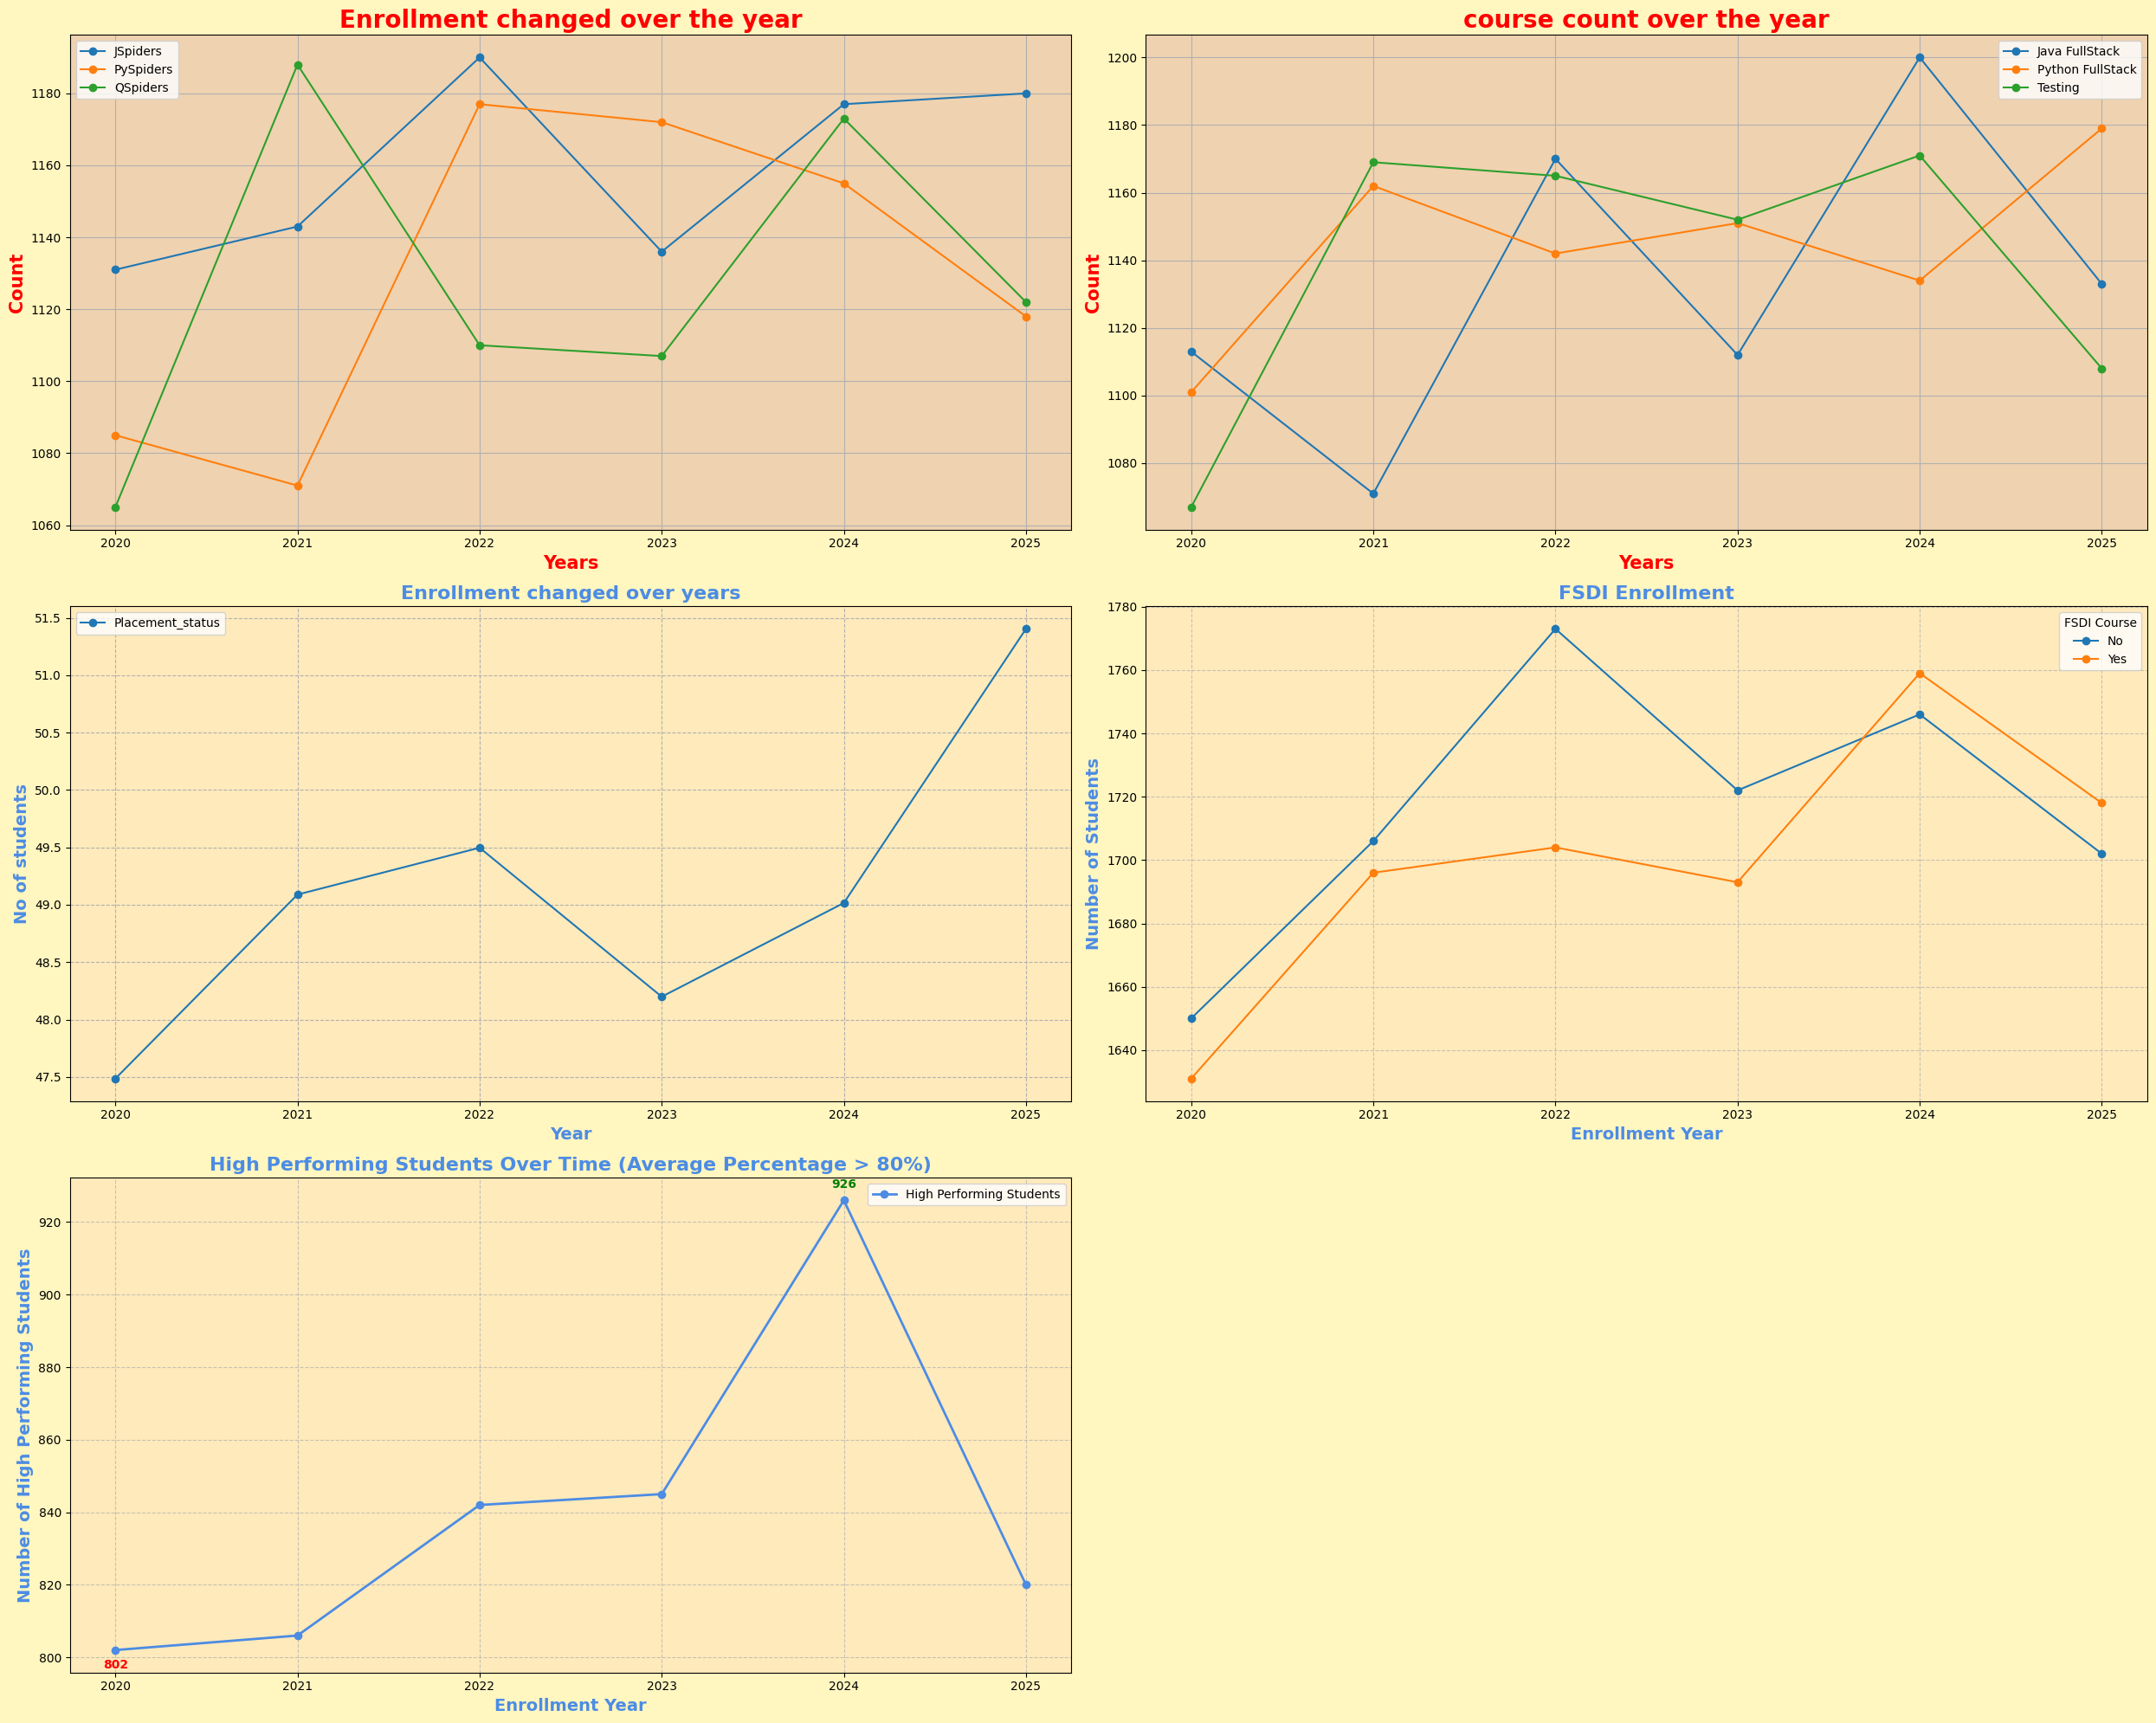

In [ ]:
plt.figure(figsize=(25, 20),facecolor='#FFF6C0')
#1
plt.subplot(3,2,1)
for i in batch:
  plt.plot(batch.index,batch[i],marker='o',label=i)
plt.xlabel('Years',color='red',fontsize=15,fontweight='bold')
plt.ylabel('Count',color='red',fontsize=15,fontweight='bold')
plt.title('Enrollment changed over the year',color='red',fontsize=20,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')

plt.legend(loc='best')
plt.grid(True)

#2
plt.subplot(3,2,2)
for i in course_data:
  plt.plot(course_data.index,course_data[i],marker='o',label=i)
plt.xlabel('Years',color='red',fontsize=15,fontweight='bold')
plt.ylabel('Count',color='red',fontsize=15,fontweight='bold')
plt.title('course count over the year',color='red',fontsize=20,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')
plt.legend(loc='best')
plt.grid(True)

#3
plt.subplot(3,2,3)
for i in placement:
  plt.plot(placement.index,placement[i],marker='o',label=i)
plt.xlabel('Year', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.ylabel('No of students', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.title('Enrollment changed over years', fontsize=16, fontweight='bold', color='#4C8CE4')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(placement.index)
plt.grid(True, linestyle='--')
plt.legend()

#4
plt.subplot(3,2,4)
for i in fsdi_enrollment:
  plt.plot(fsdi_enrollment.index,fsdi_enrollment[i],marker='o',label=i)
plt.xlabel('Enrollment Year', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.ylabel('Number of Students', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.title('FSDI Enrollment', fontsize=16, fontweight='bold', color='#4C8CE4')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(fsdi_enrollment.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='FSDI Course')

#5
plt.subplot(3,2,5)
plt.plot(high_performer_enrollment.index, high_performer_enrollment.values, marker='o', color='#4C8CE4', linewidth=2, label='High Performing Students')

max_hp_value = high_performer_enrollment.max()
min_hp_value = high_performer_enrollment.min()
max_hp_year = high_performer_enrollment.idxmax()
min_hp_year = high_performer_enrollment.idxmin()
plt.annotate(f'{int(max_hp_value)}', (max_hp_year, max_hp_value), textcoords="offset points", xytext=(0,10), ha='center', color='green', fontsize=10, fontweight='bold')
plt.annotate(f'{int(min_hp_value)}', (min_hp_year, min_hp_value), textcoords="offset points", xytext=(0,-15), ha='center', color='red', fontsize=10, fontweight='bold')

plt.xlabel('Enrollment Year', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.ylabel('Number of High Performing Students', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.title('High Performing Students Over Time (Average Percentage > 80%)', fontsize=16, fontweight='bold', color='#4C8CE4')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(high_performer_enrollment.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

In [ ]:
#:How has the number of students opting for FSDI (YES/NO) changed over the years?
fsdi_data = df[['FSDI','Year']].groupby('Year')['FSDI'].value_counts().unstack()
fsdi_data

FSDI,No,Yes
Year,,
2020,1650,1631
2021,1706,1696
2022,1773,1704
2023,1722,1693
2024,1746,1759
2025,1702,1718


In [ ]:
df[['FSDI','Year']].groupby('Year')['FSDI'].value_counts()

Year  FSDI
2020  No      1650
      Yes     1631
2021  No      1706
      Yes     1696
2022  No      1773
      Yes     1704
2023  No      1722
      Yes     1693
2024  Yes     1759
      No      1746
2025  Yes     1718
      No      1702
Name: count, dtype: int64

/tmp/ipykernel_11702/726886069.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


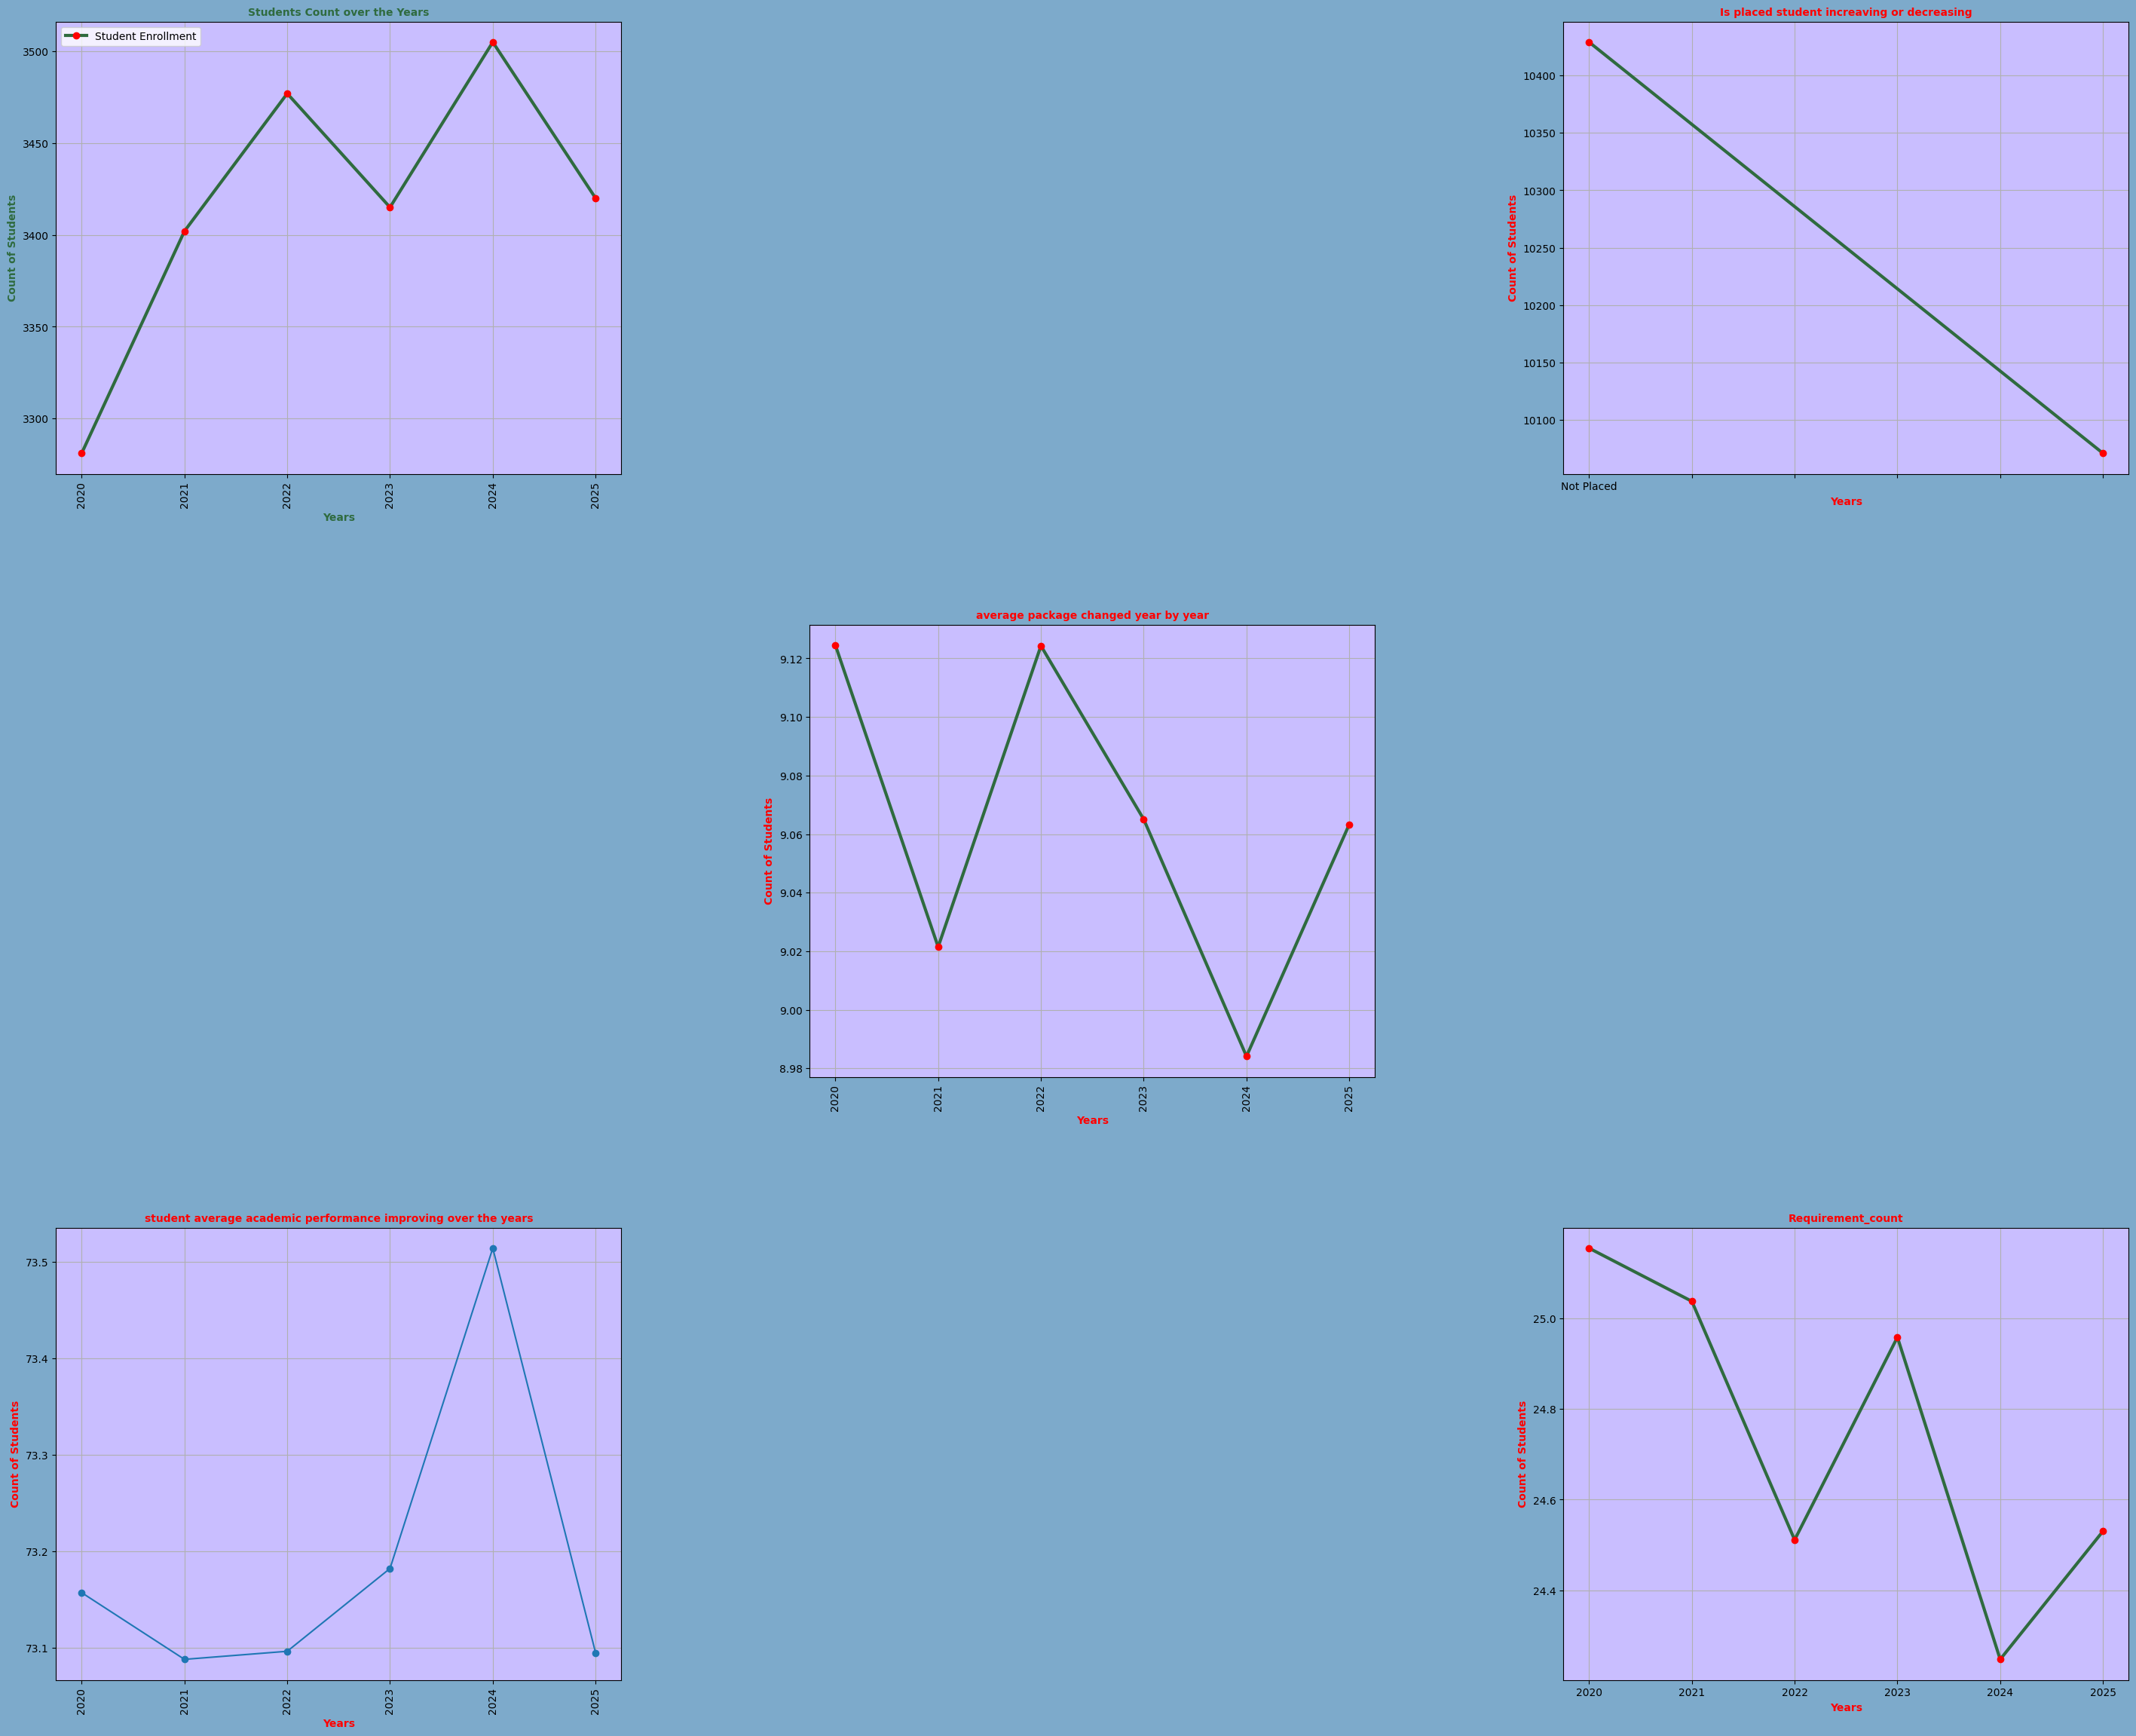

In [ ]:
fig=plt.figure(figsize=(25, 20),facecolor='#7DAACB')

#1
fig.add_axes([0.1,0.9,0.3,0.3])
a= df.groupby('Year')['Number'].count()
a.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='#2F6B3F',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='#2F6B3F',fontsize=10,fontweight='bold')
plt.title('Students Count over the Years',color='#2F6B3F',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#C9BEFF')
plt.xticks(a.index,rotation=90)
#for i ,j in zip(a.index,a.values):
    #plt.annotate(j,(i,j),ha='right',textcoords='offset points',xytext=(10,5))
# max= a.idxmax()
# min = a.idxmin()
# plt.annotate(a[max],(max,a[max]) , color='black',textcoords='offset points',xytext=(50,40),arrowprops=dict(arrowstyle='<-',lw=3,color='red'))
# plt.annotate(a[min],(min,a[min]), color='black',textcoords='offset points',xytext=(50,40),arrowprops=dict(arrowstyle='<-'))
plt.legend(loc='best')
plt.grid(True)


#2
fig.add_axes([0.9,0.9,0.3,0.3])
placed_over_time.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
plt.title('Is placed student increaving or decreasing',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#C9BEFF')
plt.grid(True)



#3
fig.add_axes([0.5,0.5,0.3,0.3])
avg_package.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
plt.title('average package changed year by year',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#C9BEFF')
plt.xticks(a.index,rotation=90)
plt.grid(True)


#4
fig.add_axes([0.1,0.1,0.3,0.3])
academic_trend.plot(marker='o')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
plt.title('student average academic performance improving over the years',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#C9BEFF')
plt.xticks(a.index,rotation=90)
plt.grid(True)

#5
fig.add_axes([0.9,0.1,0.3,0.3])
attempts.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
plt.title('Requirement_count',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#C9BEFF')
plt.grid(True)
plt.tight_layout()

/tmp/ipykernel_11702/346232826.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


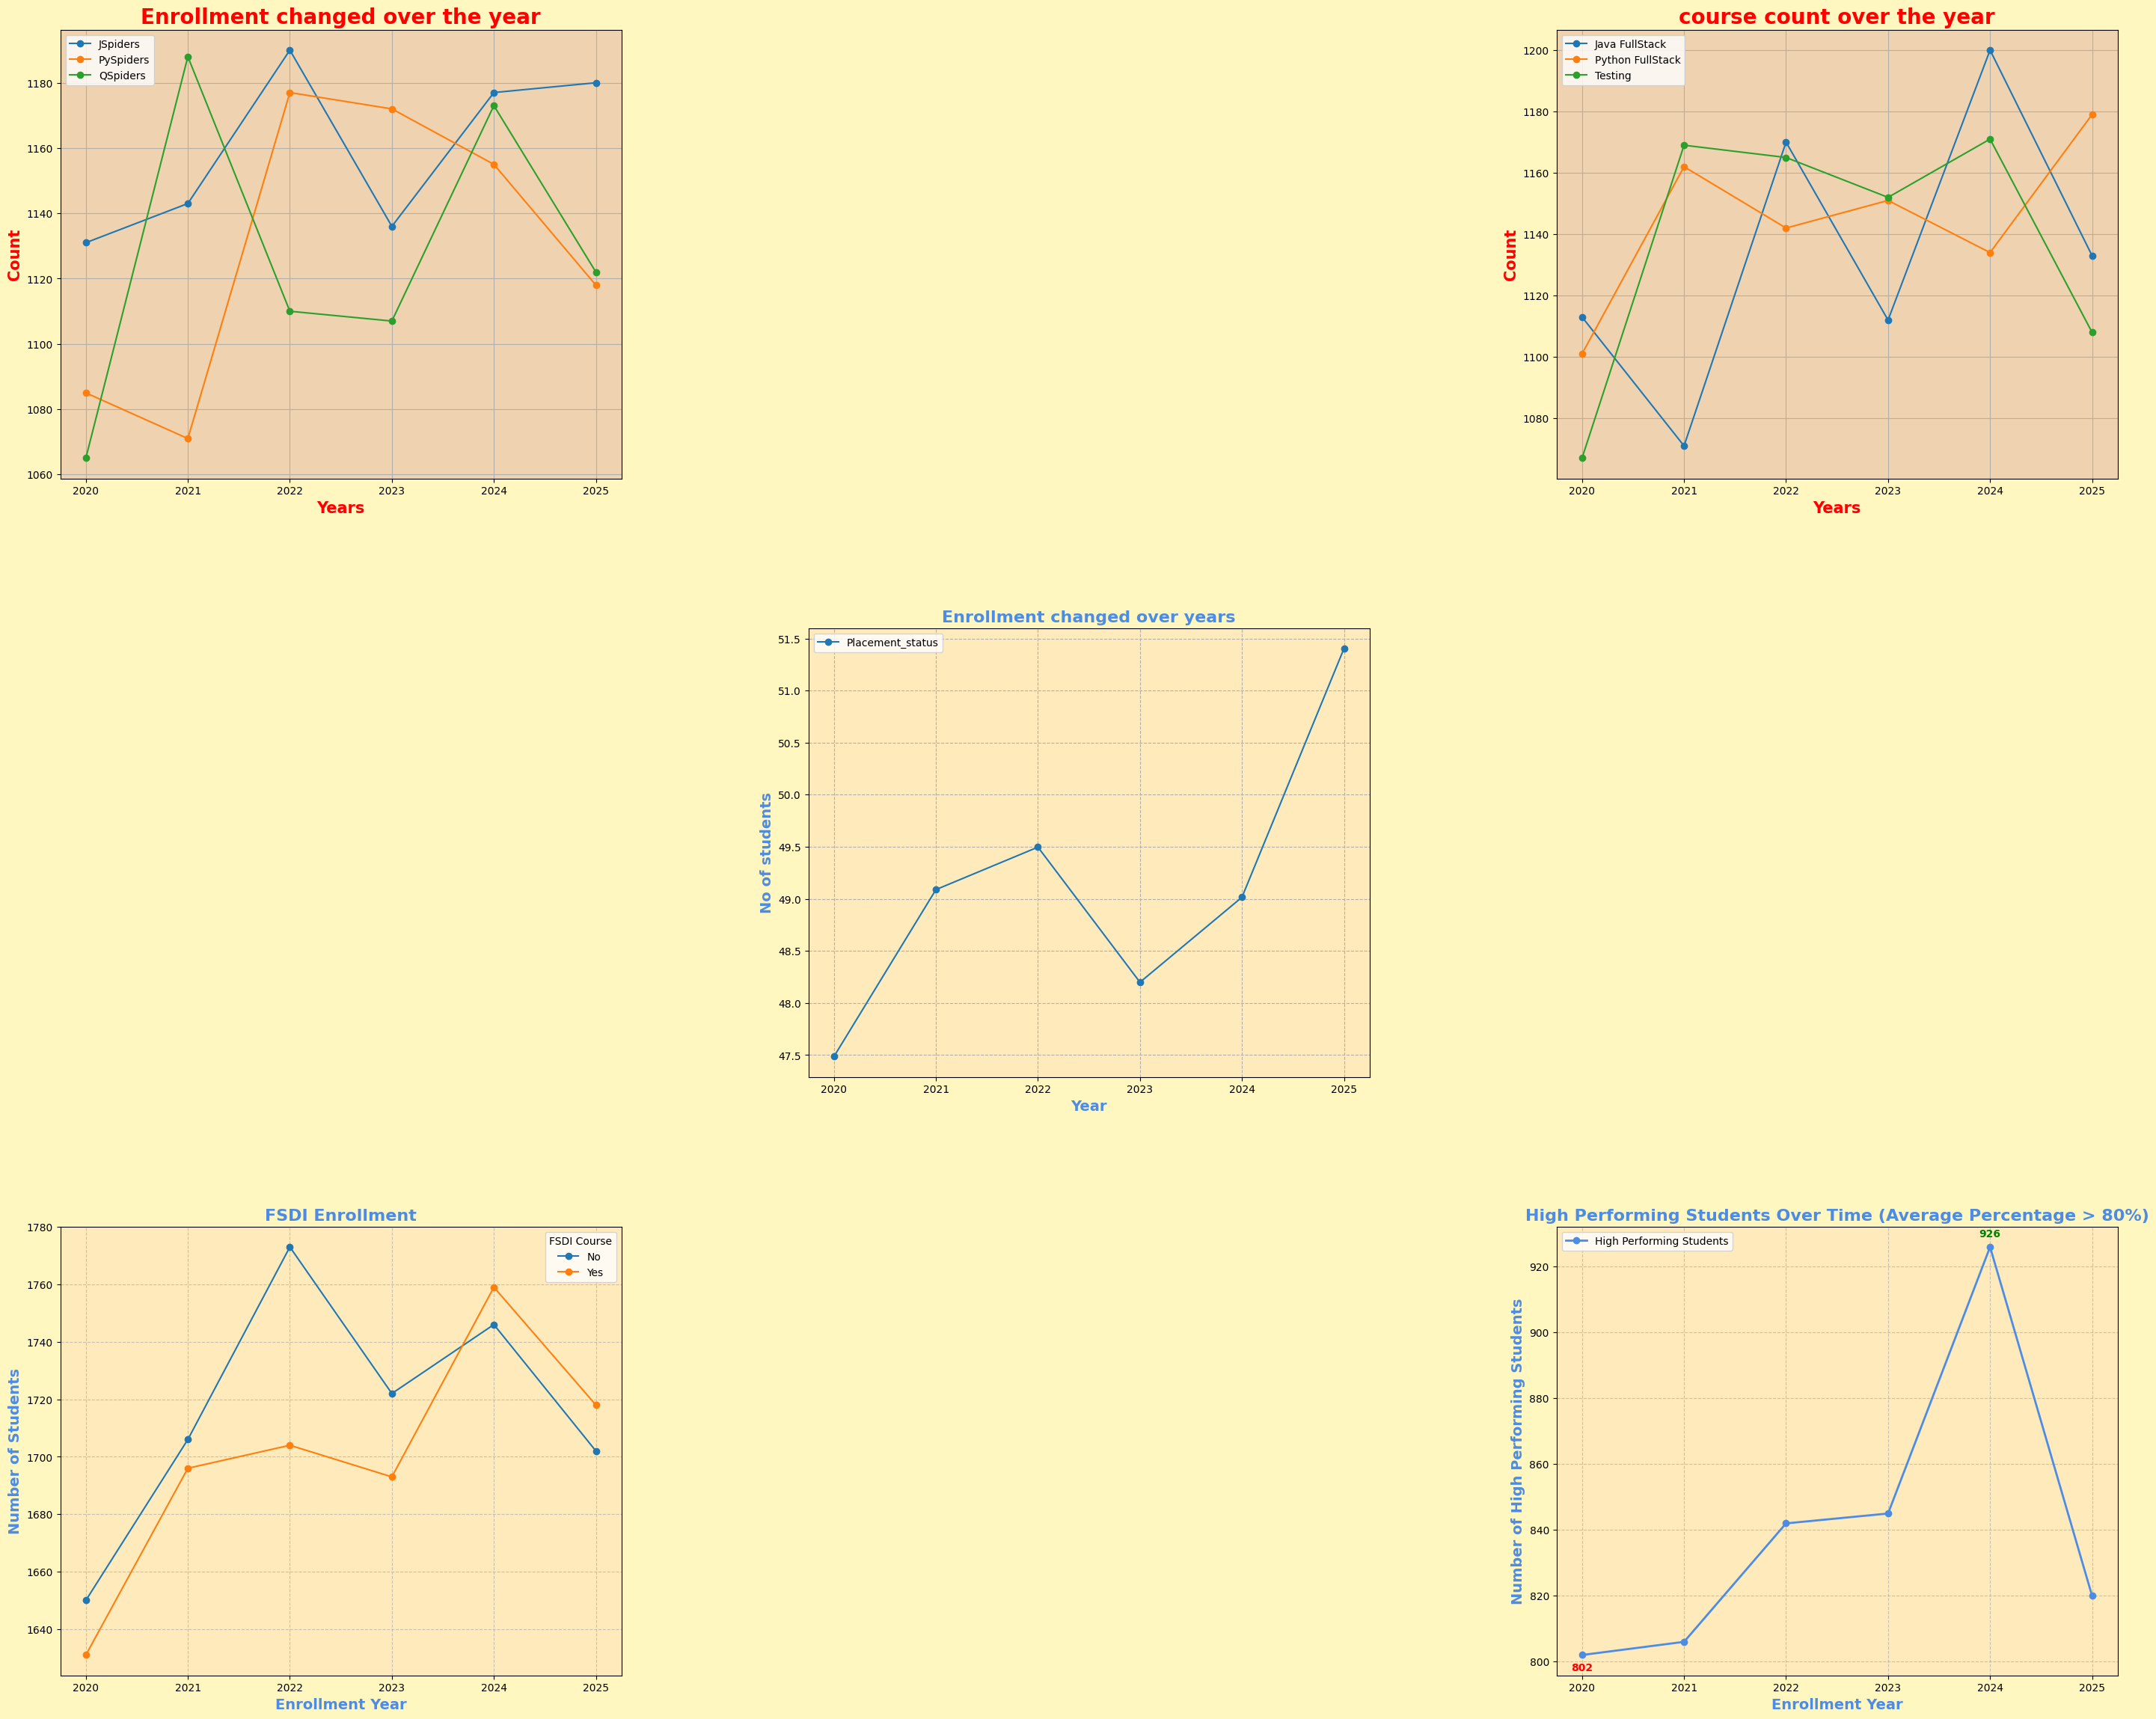

In [ ]:
fig = plt.figure(figsize=(25, 20),facecolor='#FFF6C0')

#1
fig.add_axes([0.1,0.9,0.3,0.3])
for i in batch:
  plt.plot(batch.index,batch[i],marker='o',label=i)
plt.xlabel('Years',color='red',fontsize=15,fontweight='bold')
plt.ylabel('Count',color='red',fontsize=15,fontweight='bold')
plt.title('Enrollment changed over the year',color='red',fontsize=20,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')

plt.legend(loc='best')
plt.grid(True)

#2
fig.add_axes([0.9,0.9,0.3,0.3])
for i in course_data:
  plt.plot(course_data.index,course_data[i],marker='o',label=i)
plt.xlabel('Years',color='red',fontsize=15,fontweight='bold')
plt.ylabel('Count',color='red',fontsize=15,fontweight='bold')
plt.title('course count over the year',color='red',fontsize=20,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#EFD2B0')
plt.legend(loc='best')
plt.grid(True)

#3
fig.add_axes([0.5,0.5,0.3,0.3])
for i in placement:
  plt.plot(placement.index,placement[i],marker='o',label=i)
plt.xlabel('Year', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.ylabel('No of students', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.title('Enrollment changed over years', fontsize=16, fontweight='bold', color='#4C8CE4')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(placement.index)
plt.grid(True, linestyle='--')
plt.legend()

#4
fig.add_axes([0.1,0.1,0.3,0.3])
for i in fsdi_enrollment:
  plt.plot(fsdi_enrollment.index,fsdi_enrollment[i],marker='o',label=i)
plt.xlabel('Enrollment Year', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.ylabel('Number of Students', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.title('FSDI Enrollment', fontsize=16, fontweight='bold', color='#4C8CE4')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(fsdi_enrollment.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='FSDI Course')

#5
fig.add_axes([0.9,0.1,0.3,0.3])
plt.plot(high_performer_enrollment.index, high_performer_enrollment.values, marker='o', color='#4C8CE4', linewidth=2, label='High Performing Students')

max_hp_value = high_performer_enrollment.max()
min_hp_value = high_performer_enrollment.min()
max_hp_year = high_performer_enrollment.idxmax()
min_hp_year = high_performer_enrollment.idxmin()
plt.annotate(f'{int(max_hp_value)}', (max_hp_year, max_hp_value), textcoords="offset points", xytext=(0,10), ha='center', color='green', fontsize=10, fontweight='bold')
plt.annotate(f'{int(min_hp_value)}', (min_hp_year, min_hp_value), textcoords="offset points", xytext=(0,-15), ha='center', color='red', fontsize=10, fontweight='bold')

plt.xlabel('Enrollment Year', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.ylabel('Number of High Performing Students', fontsize=14, fontweight='bold', color='#4C8CE4')
plt.title('High Performing Students Over Time (Average Percentage > 80%)', fontsize=16, fontweight='bold', color='#4C8CE4')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(high_performer_enrollment.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

In [ ]:
df


In [ ]:
place_data = df[df['Placement_status'] == 'Placed'].groupby('Year')['Number'].count()


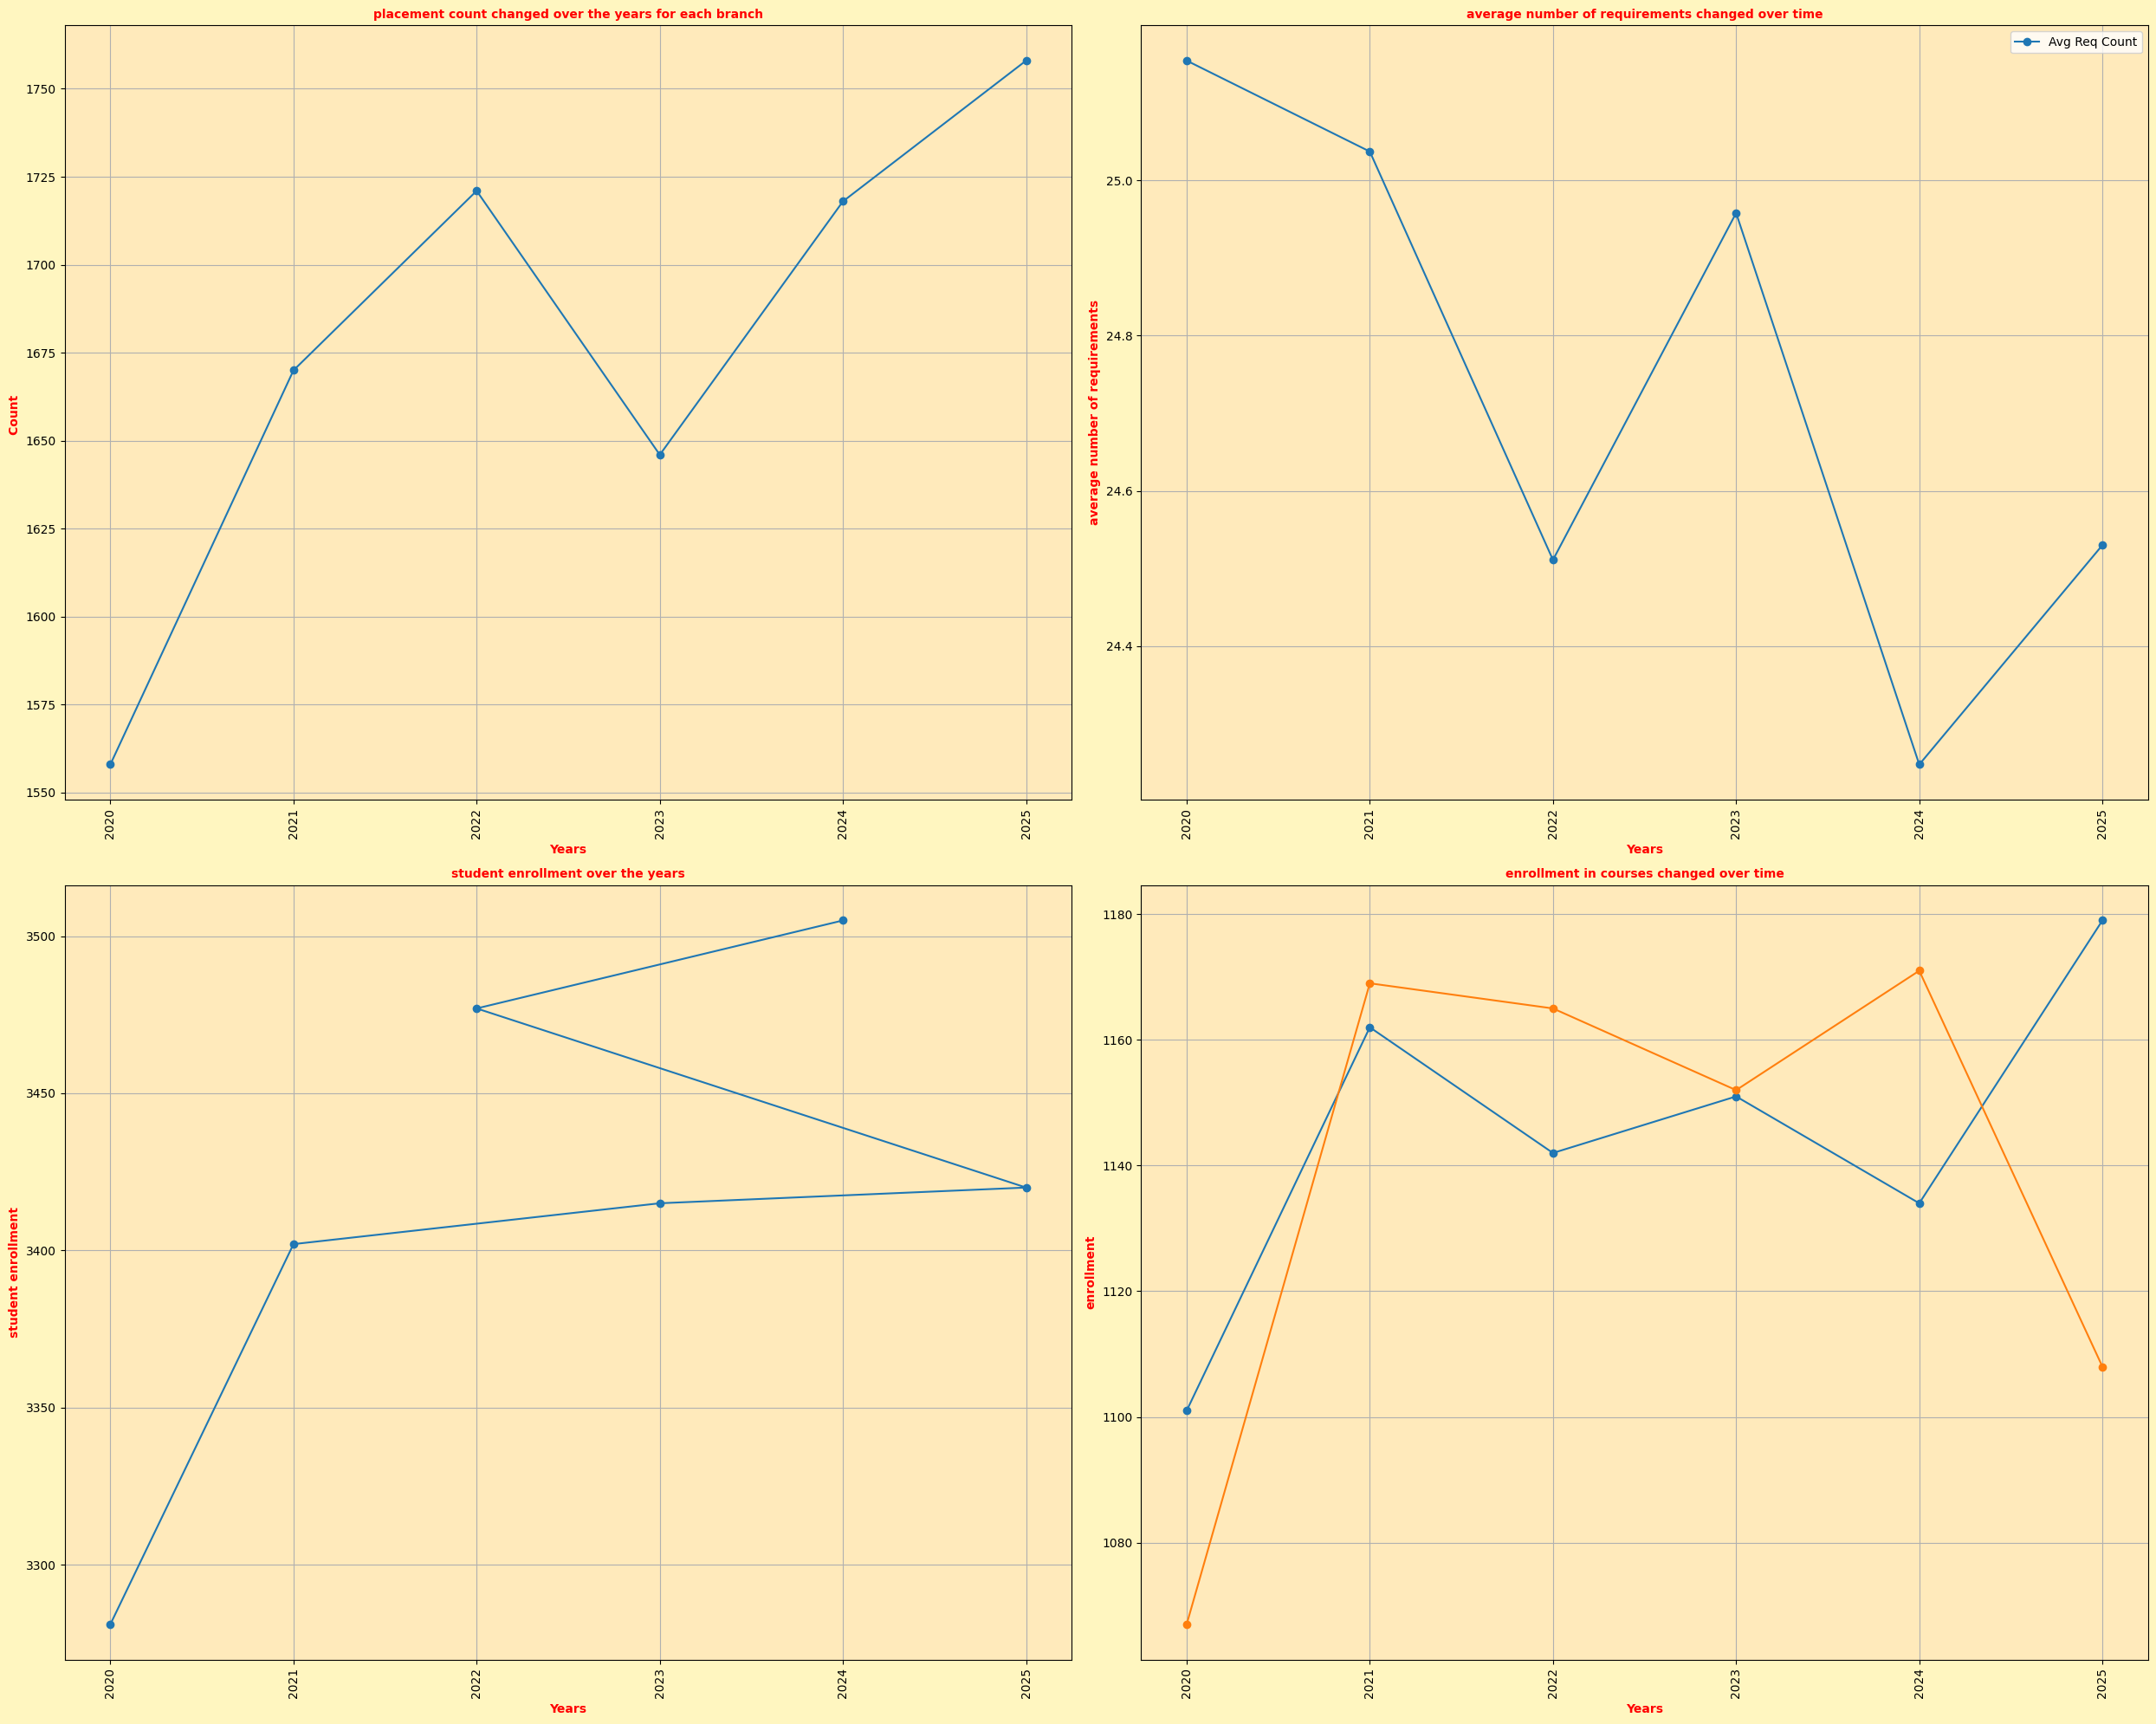

In [ ]:
plt.figure(figsize=(25, 20),facecolor='#FFF6C0')

#How has placement count changed over the years for each branch?”
plt.subplot(2,2,1)
place_data = df[df['Placement_status'] == 'Placed'].groupby('Year')['Number'].count()
plt.plot(place_data.index,place_data.values,label='Placement Count',marker='o')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count ',color='red',fontsize=10,fontweight='bold')
plt.title('placement count changed over the years for each branch',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(a.index,rotation=90)
plt.grid(True)

#How has the average number of requirements (attempts) changed over time?
plt.subplot(2,2,2)
avg_req = df.groupby('Year')['Requirement_count'].mean()
plt.plot(avg_req.index,avg_req.values,marker='o',label='Avg Req Count')
plt.legend()
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('average number of requirements',color='red',fontsize=10,fontweight='bold')
plt.title('average number of requirements changed over time',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(a.index,rotation=90)
plt.grid(True)

#student enrollment over the years
plt.subplot(2,2,3)
enroll_data = df['Year'].value_counts()
plt.plot(enroll_data.index,enroll_data.values,marker='o')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('student enrollment',color='red',fontsize=10,fontweight='bold')
plt.title('student enrollment over the years',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(a.index,rotation=90)
plt.grid(True)

#How has enrollment in testing courses vs programming courses changed over time?
plt.subplot(2,2,4)
cour_data = df.groupby('Year')['course'].value_counts().unstack()
cour_data  = cour_data.loc[:,['Python FullStack','Testing']]
for i in cour_data.columns:
    plt.plot(cour_data.index,cour_data[i],marker='o',label=i)
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('enrollment',color='red',fontsize=10,fontweight='bold')
plt.title('enrollment in courses changed over time',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(a.index,rotation=90)
plt.grid(True)
plt.tight_layout()


In [ ]:
fig1 = fig.add_axes([0.1,0.9,0.3,0.3])
fig1.plot(x,y)
fig.add_axes([0.9,0.9,0.3,0.3])
fig.add_axes([0.5,0.5,0.3,0.3])
fig.add_axes([0.1,0.1,0.3,0.3])
fig.add_axes([0.9,0.1,0.3,0.3])

/tmp/ipykernel_11702/3457004484.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


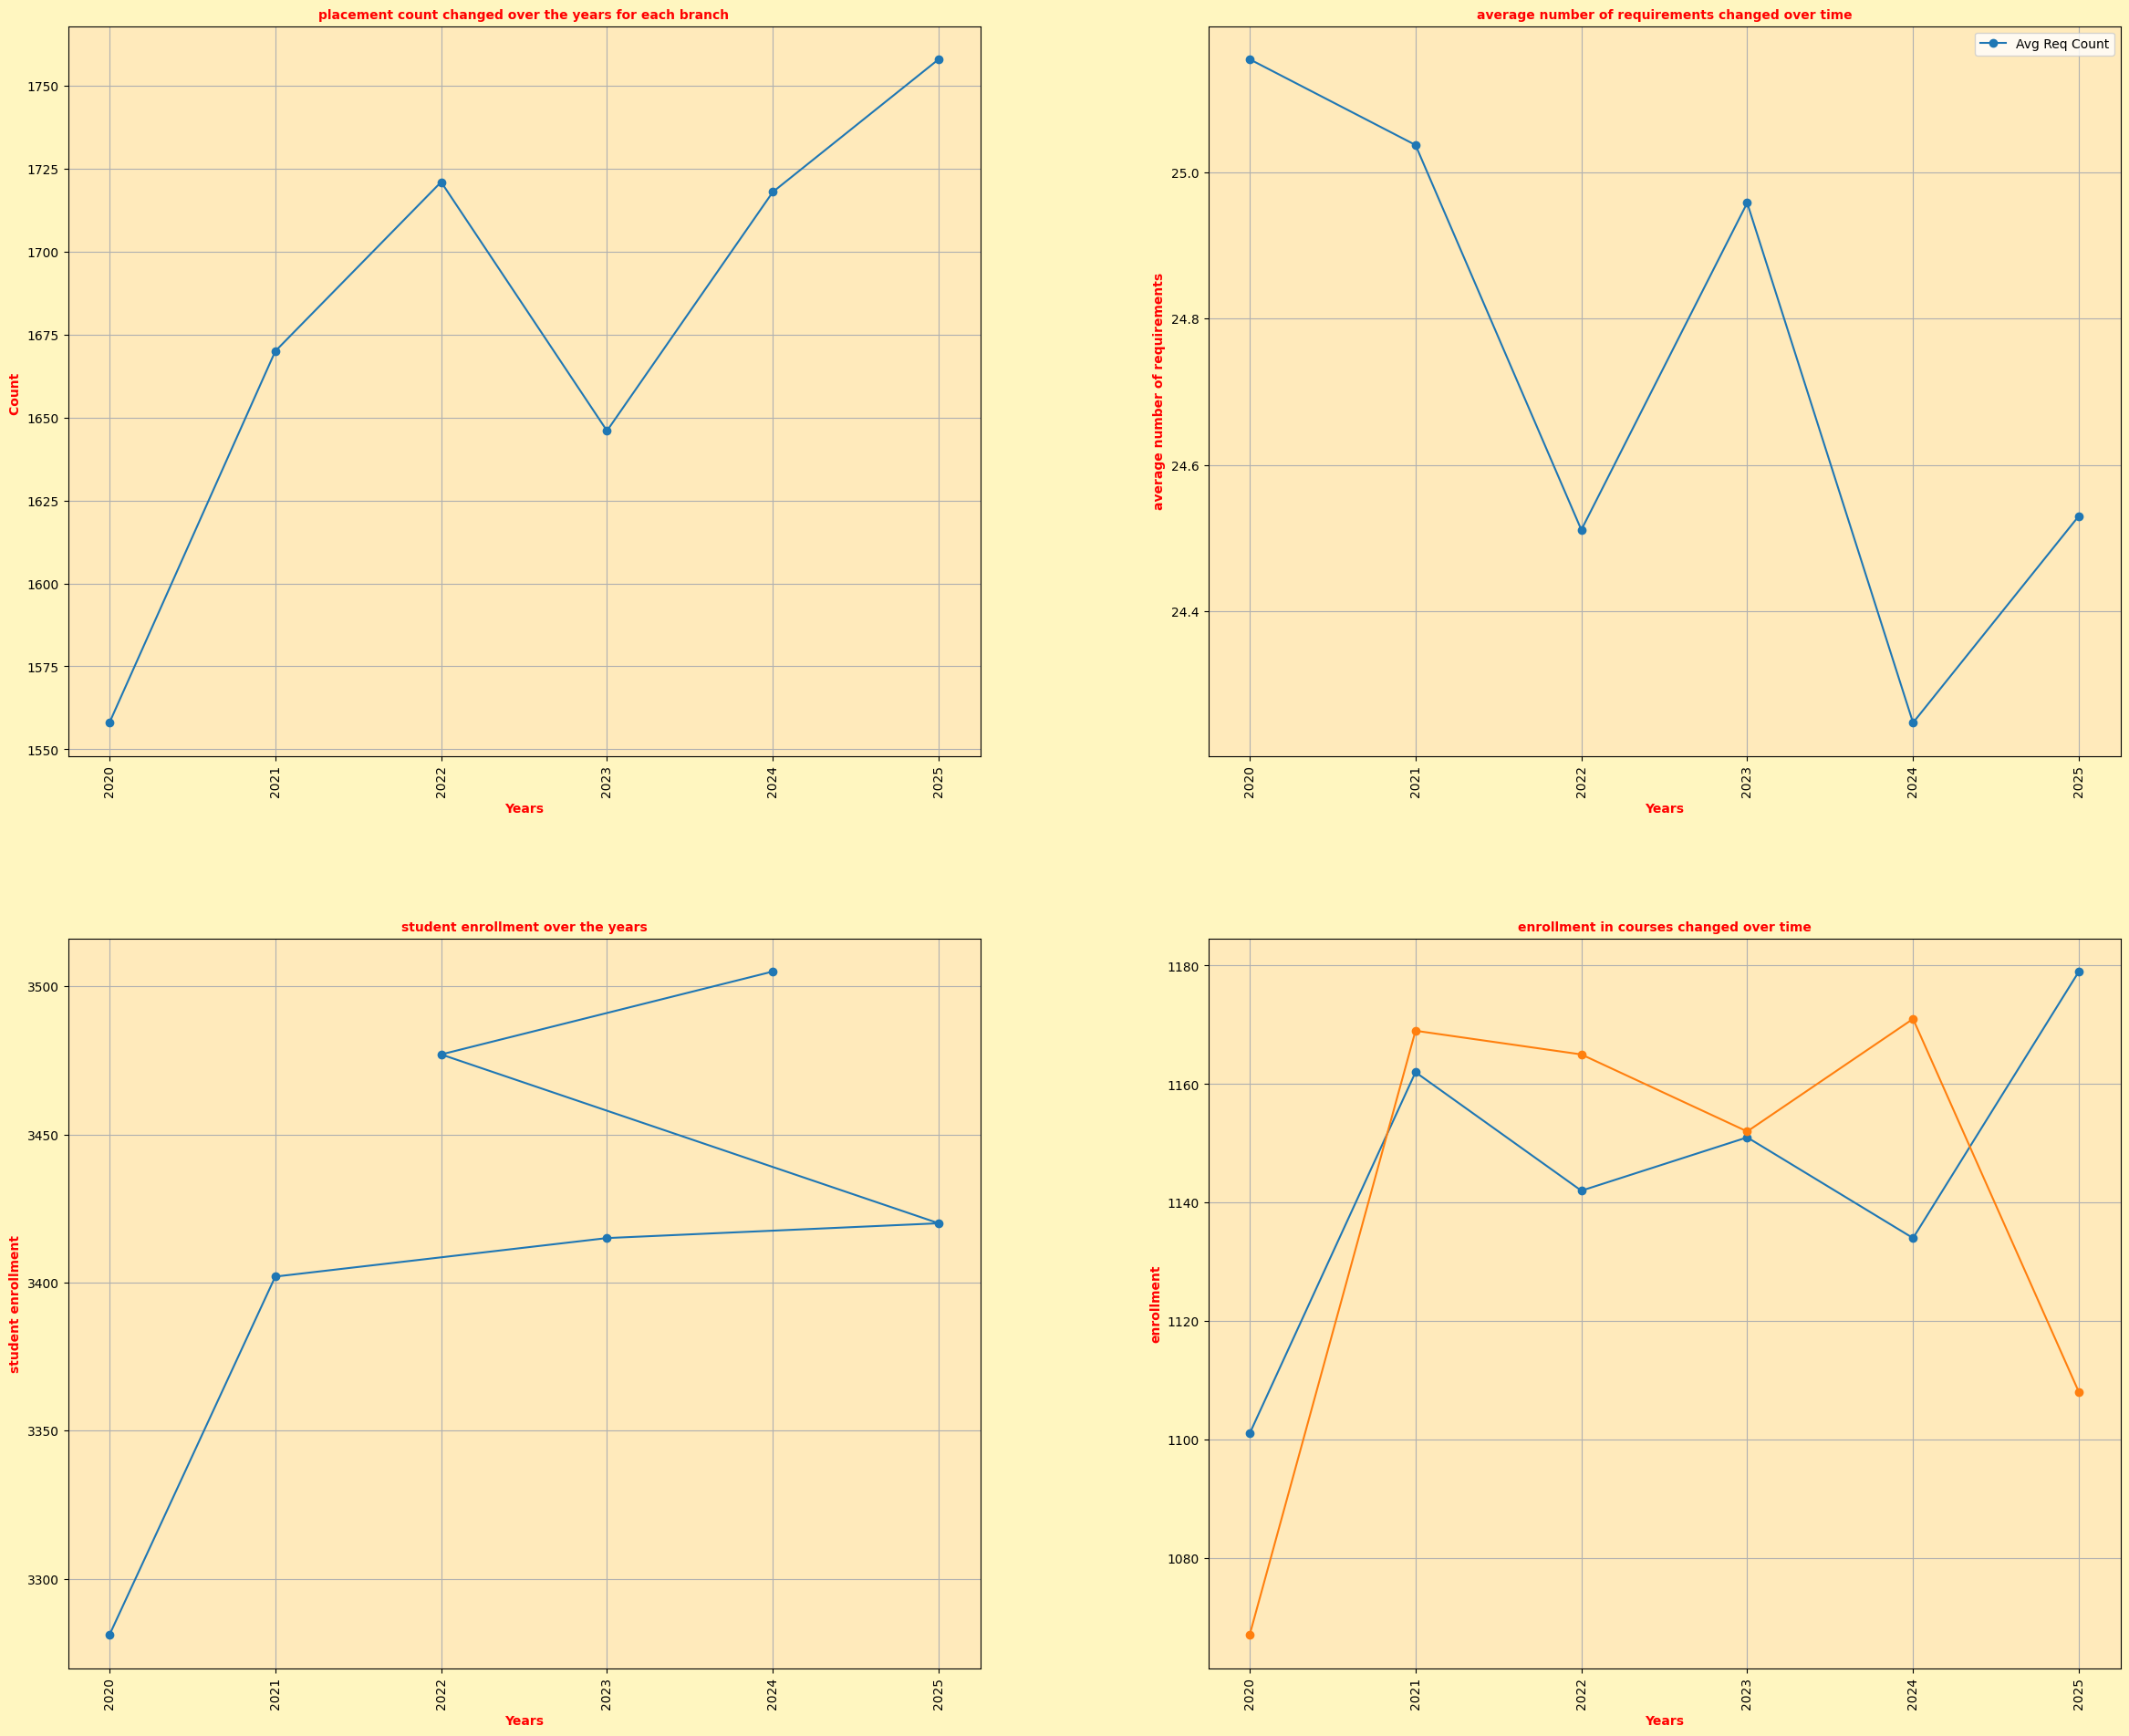

In [ ]:
fig = plt.figure(figsize=(25, 20),facecolor='#FFF6C0')

#How has placement count changed over the years for each branch?”
fig.add_axes([0.1,0.6,0.4,0.4])
place_data = df[df['Placement_status'] == 'Placed'].groupby('Year')['Number'].count()
plt.plot(place_data.index,place_data.values,label='Placement Count',marker='o')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count ',color='red',fontsize=10,fontweight='bold')
plt.title('placement count changed over the years for each branch',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(a.index,rotation=90)
plt.grid(True)

#How has the average number of requirements (attempts) changed over time?
fig.add_axes([0.6,0.6,0.4,0.4])
avg_req = df.groupby('Year')['Requirement_count'].mean()
plt.plot(avg_req.index,avg_req.values,marker='o',label='Avg Req Count')
plt.legend()
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('average number of requirements',color='red',fontsize=10,fontweight='bold')
plt.title('average number of requirements changed over time',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(a.index,rotation=90)
plt.grid(True)

#student enrollment over the years
fig.add_axes([0.1,0.1,0.4,0.4])
enroll_data = df['Year'].value_counts()
plt.plot(enroll_data.index,enroll_data.values,marker='o')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('student enrollment',color='red',fontsize=10,fontweight='bold')
plt.title('student enrollment over the years',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(a.index,rotation=90)
plt.grid(True)

#How has enrollment in testing courses vs programming courses changed over time?
fig.add_axes([0.6,0.1,0.4,0.4])
cour_data = df.groupby('Year')['course'].value_counts().unstack()
cour_data  = cour_data.loc[:,['Python FullStack','Testing']]
for i in cour_data.columns:
    plt.plot(cour_data.index,cour_data[i],marker='o',label=i)
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('enrollment',color='red',fontsize=10,fontweight='bold')
plt.title('enrollment in courses changed over time',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#FFEABB')
plt.xticks(a.index,rotation=90)
plt.grid(True)
plt.tight_layout()


/tmp/ipykernel_11702/2796352302.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


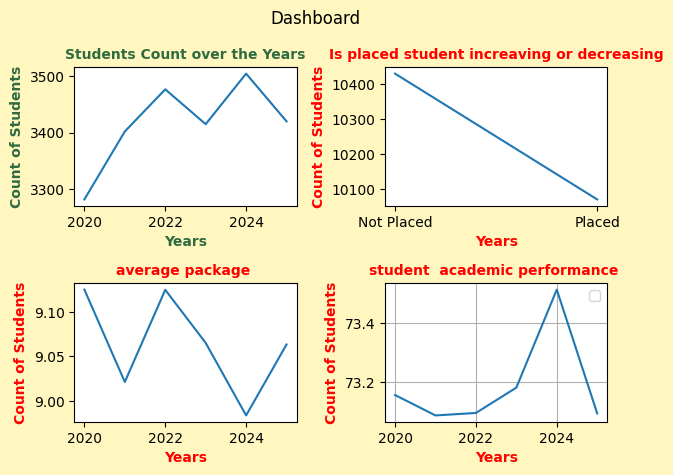

In [ ]:
fig,ax=plt.subplots(2,2)
fig.set_facecolor('#FFF6C0')
fig.suptitle('Dashboard')
#1
ax[0,0].plot(a.index,a)
ax[0,1].plot(placed_over_time.index,placed_over_time)
ax[1,0].plot(avg_package.index,avg_package)
ax[1,1].plot(academic_trend.index,academic_trend)

ax[0,0].set_xlabel('Years',color='#2F6B3F',fontsize=10,fontweight='bold')
ax[0,0].set_ylabel('Count of Students',color='#2F6B3F',fontsize=10,fontweight='bold')
ax[0,0].set_title('Students Count over the Years',color='#2F6B3F',fontsize=10,fontweight='bold')


plt.legend(loc='best')
plt.grid(True)


#2
ax[0,1].set_xlabel('Years',color='red',fontsize=10,fontweight='bold')
ax[0,1].set_ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
ax[0,1].set_title('Is placed student increaving or decreasing',color='red',fontsize=10,fontweight='bold')
#ax = plt.gca()
#ax.set_facecolor('#EFD2B0')
plt.grid(True)



#3
ax[1,0].set_xlabel('Years',color='red',fontsize=10,fontweight='bold')
ax[1,0].set_ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
ax[1,0].set_title('average package ',color='red',fontsize=10,fontweight='bold')
#ax = plt.gca()
#ax.set_facecolor('#EFD2B0')
#plt.xticks(a.index,rotation=90)
#plt.grid(True)


#4
ax[1,1].set_xlabel('Years',color='red',fontsize=10,fontweight='bold')
ax[1,1].set_ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
ax[1,1].set_title('student  academic performance ',color='red',fontsize=10,fontweight='bold')

plt.tight_layout()



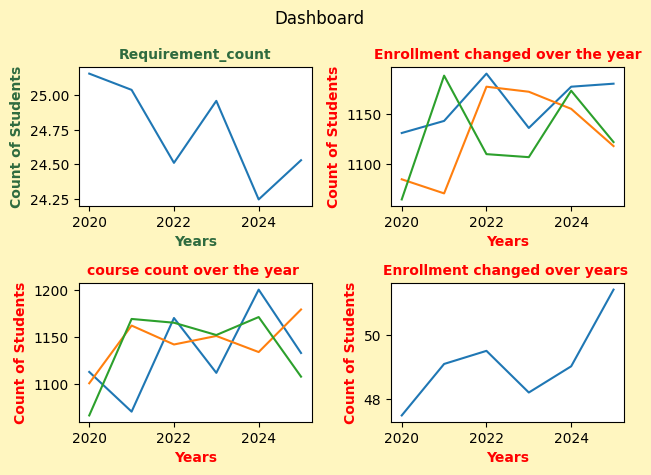

In [ ]:
fig,ax=plt.subplots(2,2)
fig.set_facecolor('#FFF6C0')
fig.suptitle('Dashboard')


ax[0,0].plot(attempts.index,attempts)
ax[0,1].plot(batch.index,batch)
ax[1,0].plot(course_data.index,course_data)
ax[1,1].plot(placement.index,placement)


#1
ax[0,0].set_xlabel('Years',color='#2F6B3F',fontsize=10,fontweight='bold')
ax[0,0].set_ylabel('Count of Students',color='#2F6B3F',fontsize=10,fontweight='bold')
ax[0,0].set_title('Requirement_count',color='#2F6B3F',fontsize=10,fontweight='bold')


#plt.grid(True)


#2
ax[0,1].set_xlabel('Years',color='red',fontsize=10,fontweight='bold')
ax[0,1].set_ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
ax[0,1].set_title('Enrollment changed over the year',color='red',fontsize=10,fontweight='bold')
#ax = plt.gca()
#ax.set_facecolor('#EFD2B0')
#plt.grid(True)



#3
ax[1,0].set_xlabel('Years',color='red',fontsize=10,fontweight='bold')
ax[1,0].set_ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
ax[1,0].set_title('course count over the year ',color='red',fontsize=10,fontweight='bold')
#ax = plt.gca()
#ax.set_facecolor('#EFD2B0')
#plt.xticks(a.index,rotation=90)
#plt.grid(True)


#4
ax[1,1].set_xlabel('Years',color='red',fontsize=10,fontweight='bold')
ax[1,1].set_ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
ax[1,1].set_title('Enrollment changed over years ',color='red',fontsize=10,fontweight='bold')

plt.tight_layout()







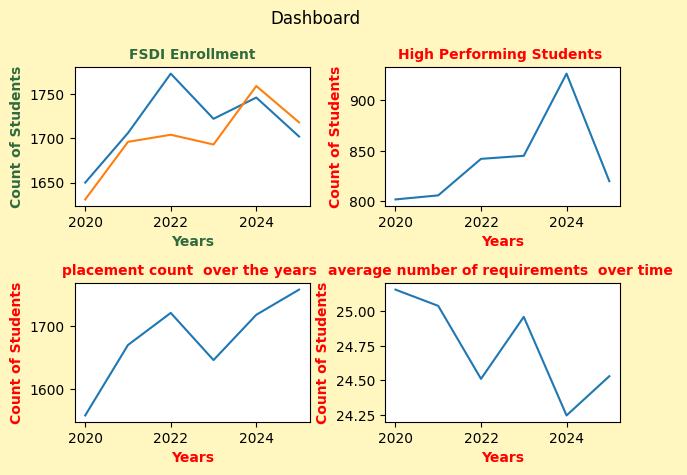

In [ ]:
fig,ax=plt.subplots(2,2)
fig.set_facecolor('#FFF6C0')
fig.suptitle('Dashboard')


ax[0,0].plot(fsdi_enrollment.index,fsdi_enrollment)
ax[0,1].plot(high_performer_enrollment.index,high_performer_enrollment)
ax[1,0].plot(place_data.index,place_data)
ax[1,1].plot(avg_req.index,avg_req)


#1
ax[0,0].set_xlabel('Years',color='#2F6B3F',fontsize=10,fontweight='bold')
ax[0,0].set_ylabel('Count of Students',color='#2F6B3F',fontsize=10,fontweight='bold')
ax[0,0].set_title('FSDI Enrollment',color='#2F6B3F',fontsize=10,fontweight='bold')


#plt.grid(True)


#2
ax[0,1].set_xlabel('Years',color='red',fontsize=10,fontweight='bold')
ax[0,1].set_ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
ax[0,1].set_title('High Performing Students ',color='red',fontsize=10,fontweight='bold')
#ax = plt.gca()
#ax.set_facecolor('#EFD2B0')
#plt.grid(True)



#3
ax[1,0].set_xlabel('Years',color='red',fontsize=10,fontweight='bold')
ax[1,0].set_ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
ax[1,0].set_title('placement count  over the years ',color='red',fontsize=10,fontweight='bold')
#ax = plt.gca()
#ax.set_facecolor('#EFD2B0')
#plt.xticks(a.index,rotation=90)
#plt.grid(True)


#4
ax[1,1].set_xlabel('Years',color='red',fontsize=10,fontweight='bold')
ax[1,1].set_ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
ax[1,1].set_title('average number of requirements  over time ',color='red',fontsize=10,fontweight='bold')

plt.tight_layout()







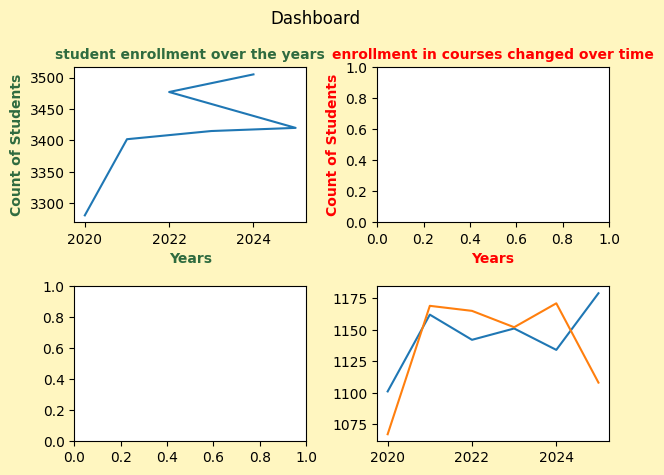

In [ ]:
fig,ax=plt.subplots(2,2)
fig.set_facecolor('#FFF6C0')
fig.suptitle('Dashboard')


ax[0,0].plot(enroll_data.index,enroll_data)

ax[1,1].plot(cour_data.index,cour_data)


#1
ax[0,0].set_xlabel('Years',color='#2F6B3F',fontsize=10,fontweight='bold')
ax[0,0].set_ylabel('Count of Students',color='#2F6B3F',fontsize=10,fontweight='bold')
ax[0,0].set_title('student enrollment over the years',color='#2F6B3F',fontsize=10,fontweight='bold')


#plt.grid(True)


#2
ax[0,1].set_xlabel('Years',color='red',fontsize=10,fontweight='bold')
ax[0,1].set_ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
ax[0,1].set_title('enrollment in courses changed over time',color='red',fontsize=10,fontweight='bold')
#ax = plt.gca()
#ax.set_facecolor('#EFD2B0')
#plt.grid(True)
plt.tight_layout()


/tmp/ipykernel_11702/581086045.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


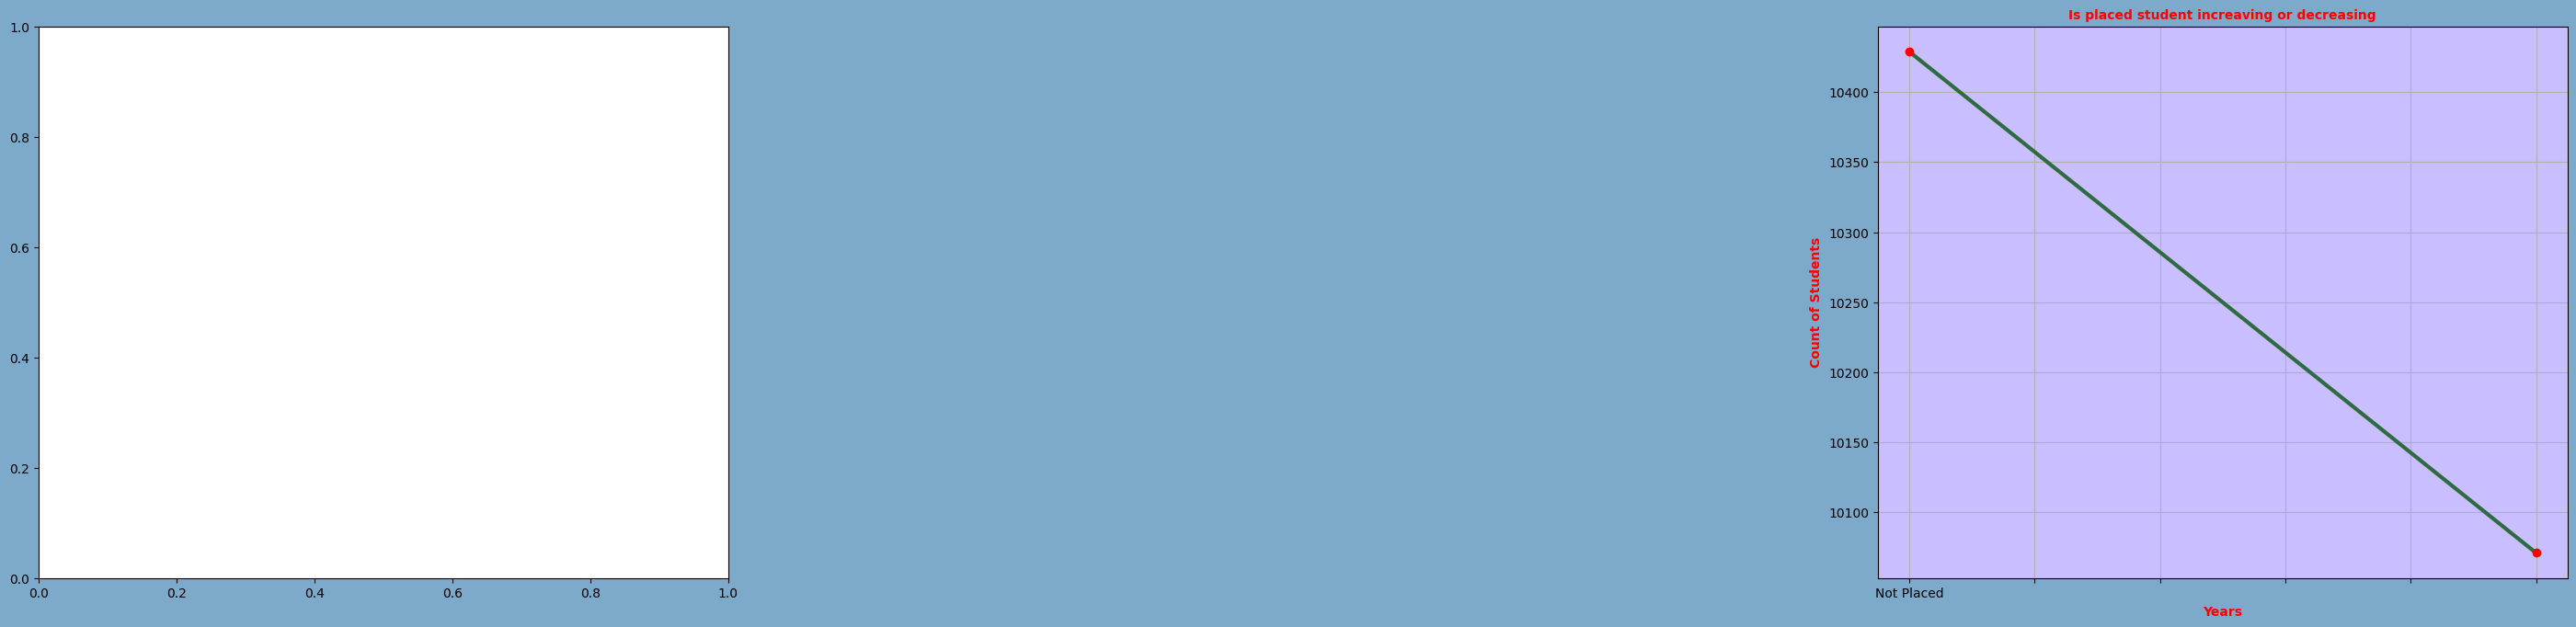

In [ ]:
fig=plt.figure(figsize=(25, 20),facecolor='#7DAACB')
fig.add_axes([0.9,0.9,0.3,0.3])
placed_over_time.plot(marker='o',markerfacecolor='red',markeredgecolor='red',color='#2F6B3F',linewidth=3,label='Student Enrollment')
plt.xlabel('Years',color='red',fontsize=10,fontweight='bold')
plt.ylabel('Count of Students',color='red',fontsize=10,fontweight='bold')
plt.title('Is placed student increaving or decreasing',color='red',fontsize=10,fontweight='bold')
ax = plt.gca()
ax.set_facecolor('#C9BEFF')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df=pd.DataFrame({'ID':[1,2,3,4,5],
                 'stream':['BE','BCA','BCOM','BSC','BBA'],
                 'students':[620,220,40,60,60]})

In [ ]:
df

,ID,stream,students
0,1,BE,620
1,2,BCA,220
2,3,BCOM,40
3,4,BSC,60
4,5,BBA,60


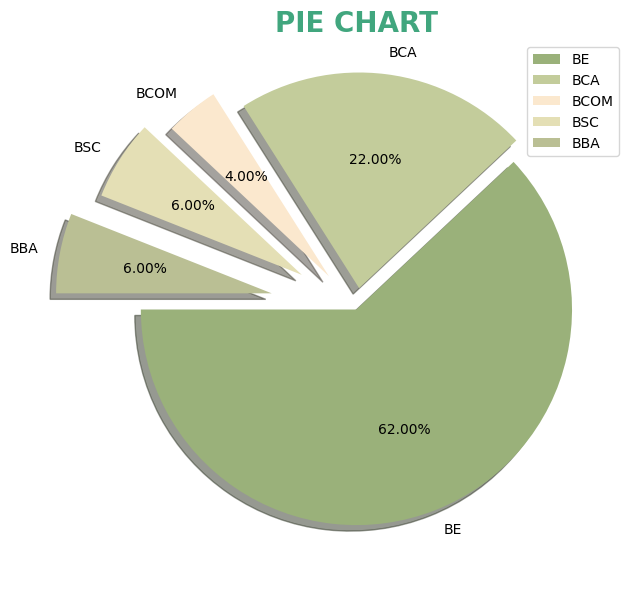

In [ ]:
plt.figure(figsize=(7,7))
plt.title('PIE CHART',color='#41A67E',fontsize=20,fontweight='bold')
plt.pie(df['students'],labels=df['stream'],autopct='%0.2f%%',colors=['#9AB17A','#C3CC9B','#FBE8CE','#E4DFB5','#BABF94'],
        explode=[0,0.1,0.2,0.3,0.4],shadow='true',startangle=180)
plt.legend()
plt.show()

In [ ]:
dff

,Name,Number,Enrollment_Date,10_yop,10_per,12_yop,12_per,degree_yop,degree_per,masters_yop,masters_per,branch,course,FSDI,Requirement_count,Placement_status,package
0,Stud00001,1,2022-05-10,2016,93,2018,78,2021.0,NaN,2023.0,61.192678,PySpiders,Testing,Yes,3,Placed,13.461957
1,Stud00002,2,2023-07-18,2017,60,2019,68,NaN,58.244181,2024.0,70.726321,JSpiders,Python FullStack,No,0,Not Placed,6.314052
2,Stud00003,3,2023-02-04,2015,96,2017,84,NaN,61.476027,2022.0,71.973305,QSpiders,Python FullStack,Yes,32,Not Placed,6.101702
3,Stud00004,4,2022-12-31,2016,75,2018,74,2021.0,NaN,2023.0,NaN,JSpiders,Java FullStack,Yes,43,Placed,14.151358
4,Stud00005,5,2024-06-26,2016,85,2018,97,NaN,70.930286,2023.0,51.893125,JSpiders,Testing,Yes,25,Not Placed,9.731116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20495,Stud20496,20496,2020-04-24,2017,68,2019,70,NaN,64.233878,2024.0,87.277097,QSpiders,Java FullStack,Yes,1,Not Placed,9.328621
20496,Stud20497,20497,2021-01-07,2015,92,2017,60,2020.0,62.108717,2022.0,NaN,QSpiders,Python FullStack,No,25,Not Placed,13.408417
20497,Stud20498,20498,2022-04-29,2016,74,2018,90,2021.0,54.013561,2023.0,83.756790,JSpiders,Python FullStack,Yes,16,Not Placed,11.757958
20498,Stud20499,20499,2025-11-07,2015,87,2017,85,2020.0,57.945448,2022.0,81.692193,PySpiders,Testing,No,34,Not Placed,4.236719


In [ ]:
#What percentage of students are placed and not_placed?
placed=df['Placement_status'].value_counts()
placed

,count
Placement_status,
Not Placed,10429
Placed,10071


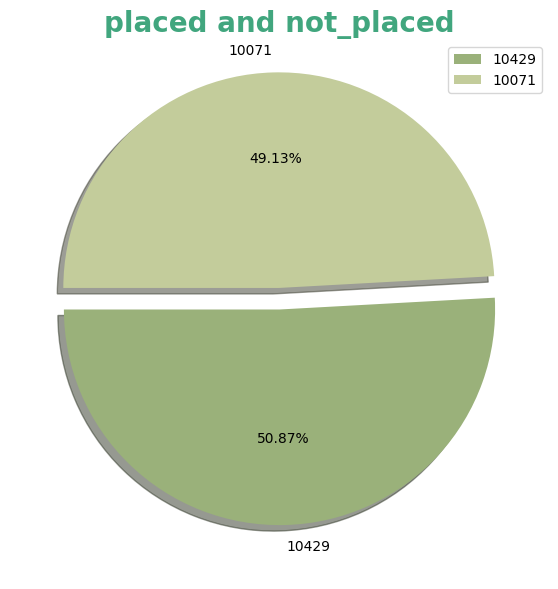

In [ ]:
plt.figure(figsize=(7,7))
plt.title('placed and not_placed',color='#41A67E',fontsize=20,fontweight='bold')
plt.pie(placed,labels=placed,autopct='%0.2f%%',colors=['#9AB17A','#C3CC9B'],
        explode=[0,0.1],shadow='true',startangle=180)
plt.legend()
plt.show()

In [ ]:
#which branch has the highest number of student
high=df['branch'].value_counts()
high

,count
branch,
JSpiders,6957
PySpiders,6778
QSpiders,6765


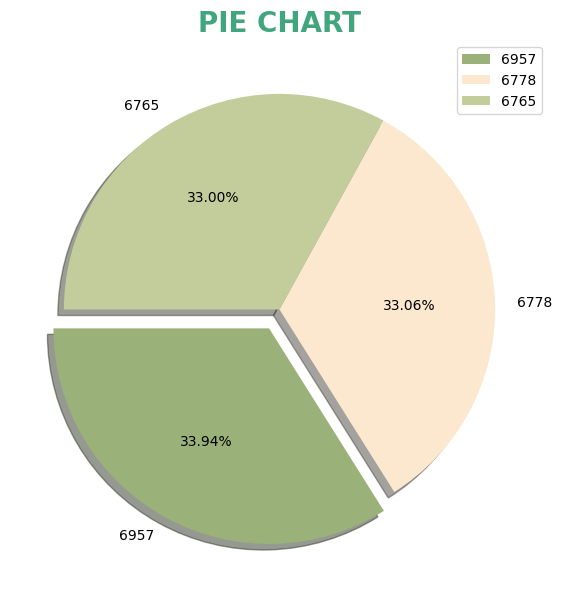

In [ ]:
plt.figure(figsize=(7,7))
plt.title('PIE CHART',color='#41A67E',fontsize=20,fontweight='bold')
plt.pie(high,labels=high,autopct='%0.2f%%',colors=['#9AB17A','#FBE8CE','#C3CC9B'],
        explode=[0.1,0,0],shadow='true',startangle=180)
plt.legend()
plt.show()

In [ ]:
#what is the distribution of students across different courses?

#how are students distributed across different FSDI category?
#What is the distribution of student across different salary range?